# ANALISIS DE DATOS - TP


Ideas:
* De la fecha-- >sacar dia de la semana (L, M, ...), feriado, fin de semana, madrugada, tarde, noche..
* Eliminar 
    año
    location --> la misma info esta en latitude y longitude
    ID
    Case number --> sirve para detectar duplicados, despues no interesa
    Update on?
* Inferir faltantes de otros campos
* Columnas con muchas categorias --> reducir y agrupar por OTHERS?
* Aplicar chi2, pca entre categoricas
* Usar dython.nominal python


## Importar libs y datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import category_encoders as ce
import holidays
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest,SelectFpr, chi2, f_classif, mutual_info_classif
from dython.nominal import associations, correlation_ratio, cramers_v
import prince
from sklearn.decomposition import PCA
from imblearn.under_sampling import RandomUnderSampler

In [2]:
df = pd.read_csv('./dataset/Crimes_-_2024_20251103.csv', na_values='sin especificar', encoding='ISO-8859-1')
us_holidays = holidays.US(years=[2024])  # Cargar feriados de EE.UU. para los años 2024

## Analisis preliminar de los datos

In [3]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13709672,JJ101940,12/31/2024 11:58:00 PM,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,5,43,14,1186817.0,1860189.0,2024,11/02/2025 03:41:09 PM,41.771470,-87.590742,POINT (-87.59074212 41.771470188)
1,13707925,JJ100089,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,...,3,38,26,1179661.0,1873623.0,2024,05/17/2025 03:40:52 PM,41.808501,-87.616563,POINT (-87.616562762 41.808500903)
2,13708038,JJ100035,12/31/2024 11:55:00 PM,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,...,18,70,04B,1145740.0,1853048.0,2024,11/02/2025 03:41:09 PM,41.752749,-87.741498,POINT (-87.741497836 41.752748627)
3,13709164,JJ101392,12/31/2024 11:53:00 PM,066XX S GREENWOOD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,20,42,14,1184362.0,1861188.0,2024,11/02/2025 03:41:09 PM,41.774269,-87.599710,POINT (-87.599709962 41.774269351)
4,13707823,JJ100020,12/31/2024 11:50:00 PM,012XX N MENARD AVE,0460,BATTERY,SIMPLE,SIDEWALK,False,False,...,29,25,08B,1137458.0,1907694.0,2024,05/17/2025 03:40:52 PM,41.902858,-87.770537,POINT (-87.770536741 41.902858242)


In [217]:
print("Column || Missing || Type || Unique Values (first 5)")
for col in df.columns:
    print(f"* {col} || {len(df[col].unique())} || {df[col].isna().sum()} || {df[col].dtype} || {df[col].dropna().unique()[:5]}")
    

Column || Missing || Type || Unique Values (first 5)
* Date || 128780 || 0 || object || ['12/31/2024 11:58:00 PM' '12/31/2024 11:56:00 PM'
 '12/31/2024 11:55:00 PM' '12/31/2024 11:53:00 PM'
 '12/31/2024 11:50:00 PM']
* Block || 28656 || 0 || object || ['014XX E 68TH ST' '047XX S DR MARTIN LUTHER KING JR DR'
 '077XX S CICERO AVE' '066XX S GREENWOOD AVE' '012XX N MENARD AVE']
* IUCR || 340 || 0 || object || ['1310' '1365' '0498' '1320' '0460']
* Primary Type || 31 || 0 || object || ['CRIMINAL DAMAGE' 'CRIMINAL TRESPASS' 'BATTERY' 'MOTOR VEHICLE THEFT'
 'OTHER OFFENSE']
* Description || 318 || 0 || object || ['TO PROPERTY' 'TO RESIDENCE'
 'AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SERIOUS INJURY' 'TO VEHICLE'
 'SIMPLE']
* Location Description || 129 || 0 || object || ['APARTMENT' 'HOTEL / MOTEL' 'STREET' 'SIDEWALK' 'CTA BUS']
* Arrest || 2 || 0 || bool || [False  True]
* Domestic || 2 || 0 || bool || [False  True]
* Beat || 275 || 0 || int64 || [ 332  223  834  321 2531]
* District || 2

In [13]:
df[df['X Coordinate'].isnull() & df['Location Description'].notnull()]['Primary Type'].unique()

array(['THEFT', 'DECEPTIVE PRACTICE', 'OTHER OFFENSE', 'HOMICIDE',
       'OFFENSE INVOLVING CHILDREN', 'CRIMINAL SEXUAL ASSAULT',
       'PUBLIC PEACE VIOLATION', 'CRIMINAL DAMAGE', 'SEX OFFENSE',
       'NARCOTICS', 'BATTERY', 'ASSAULT', 'BURGLARY', 'CRIMINAL TRESPASS',
       'INTERFERENCE WITH PUBLIC OFFICER', 'MOTOR VEHICLE THEFT',
       'ROBBERY', 'WEAPONS VIOLATION', 'ARSON', 'PROSTITUTION',
       'STALKING', 'KIDNAPPING', 'OBSCENITY', 'INTIMIDATION'],
      dtype=object)

In [218]:
df.describe()

,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,is_holiday,date_dt,...,Domestic_code,kbin_latitude,kbin_longitude,kbin_x_coordinate,kbin_y_coordinate,x_xoordinate_scaled,y_coordinate_scaled,latitude_scaled,longitude_scaled,x_coordinate_scaled
count,258754.000000,258754.000000,258754.000000,258754.000000,2.587540e+05,2.587540e+05,258754.000000,258754.000000,258754.000000,258754,...,258754.000000,258754.000000,258754.000000,258754.000000,258754.000000,258754.000000,258754.000000,258754.000000,258754.000000,258754.000000
mean,1157.181535,11.341958,23.186930,36.181489,1.165280e+06,1.887738e+06,41.847535,-87.668950,0.029074,2024-07-02 18:16:17.573362688,...,0.183781,0.820594,1.088517,1.097394,0.820470,0.645784,0.536649,0.536952,0.647789,0.645784
min,111.000000,1.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.934567,0.000000,2024-01-01 00:00:00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,533.000000,5.000000,10.000000,22.000000,1.154004e+06,1.860548e+06,41.772686,-87.709911,0.000000,2024-04-07 14:30:00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.545531,0.339043,0.338917,0.547894,0.545531
50%,1034.000000,10.000000,23.000000,32.000000,1.167126e+06,1.894415e+06,41.866061,-87.661858,0.000000,2024-07-03 21:00:00,...,0.000000,1.000000,1.000000,1.000000,1.000000,0.662200,0.585177,0.585969,0.665086,0.662200
75%,1732.000000,17.000000,34.000000,53.000000,1.176634e+06,1.910462e+06,41.910077,-87.627360,0.000000,2024-09-27 03:56:45,...,0.000000,1.000000,2.000000,2.000000,1.000000,0.746737,0.701801,0.702427,0.749219,0.746737
max,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.524531,1.000000,2024-12-31 23:58:00,...,1.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,709.325680,7.087948,13.949929,21.608592,1.615849e+04,3.154156e+04,0.086733,0.058839,0.168014,NaN,...,0.387306,0.766945,0.766226,0.766962,0.766361,0.143667,0.229233,0.229478,0.143497,0.143667


In [10]:
df.shape

(258792, 22)

## Analisis Nulos

In [7]:
# Contar la proporción de valores nulos en cada columna
df.isna().sum()[df.isna().sum() > 0]  

Location    1196
dtype: int64

### Location Description

In [181]:
df[df[['Longitude']].isnull().any(axis=1)]

,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,...,Updated On,Latitude,Longitude,is_holiday,date_dt,part_of_day,month,day_week,Arrest_code,Domestic_code
4719,12/24/2024 12:00:00 AM,XX S,0810,THEFT,OVER $500,APARTMENT,False,False,725,7,...,04/30/2025 03:40:03 PM,NaN,NaN,0,2024-12-24 00:00:00,Night,12,Tuesday,0,0
107229,08/01/2024 01:30:00 PM,041XX W 13th St,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NOT_DEFINED,False,False,1011,10,...,10/24/2025 03:42:34 PM,NaN,NaN,0,2024-08-01 13:30:00,Afternoon,8,Thursday,0,0
167753,05/15/2024 03:00:00 AM,002XX W ROOSEVELT RD,0460,BATTERY,SIMPLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,123,1,...,05/16/2025 03:41:35 PM,NaN,NaN,0,2024-05-15 03:00:00,Night,5,Wednesday,0,0
167768,05/15/2024 01:50:00 AM,065XX S HAMLIN AVE,502P,OTHER OFFENSE,FALSE / STOLEN / ALTERED TRP,STREET,False,False,833,8,...,05/16/2025 03:41:35 PM,NaN,NaN,0,2024-05-15 01:50:00,Night,5,Wednesday,0,0
167790,05/15/2024 01:00:00 AM,042XX N PARKSIDE AVE,0810,THEFT,OVER $500,STREET,False,False,1624,16,...,05/16/2025 03:41:35 PM,NaN,NaN,0,2024-05-15 01:00:00,Night,5,Wednesday,0,0
167809,05/15/2024 12:01:00 AM,060XX W 60TH ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,812,8,...,05/16/2025 03:41:35 PM,NaN,NaN,0,2024-05-15 00:01:00,Night,5,Wednesday,0,0
167843,05/15/2024 12:00:00 AM,060XX W DAKIN ST,1130,DECEPTIVE PRACTICE,FRAUD OR CONFIDENCE GAME,RESIDENCE,False,False,1633,16,...,05/16/2025 03:41:35 PM,NaN,NaN,0,2024-05-15 00:00:00,Night,5,Wednesday,0,0
167845,05/14/2024 11:59:00 PM,030XX W 72ND ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,831,8,...,05/16/2025 03:41:35 PM,NaN,NaN,0,2024-05-14 23:59:00,Night,5,Tuesday,1,0
167919,05/14/2024 09:19:00 PM,008XX W 65TH ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,723,7,...,05/16/2025 03:41:35 PM,NaN,NaN,0,2024-05-14 21:19:00,Evening,5,Tuesday,1,0
167931,05/14/2024 09:00:00 PM,071XX W WELLINGTON AVE,0920,MOTOR VEHICLE THEFT,ATTEMPT - AUTOMOBILE,STREET,False,False,2511,25,...,05/16/2025 03:41:35 PM,NaN,NaN,0,2024-05-14 21:00:00,Evening,5,Tuesday,0,0


In [186]:
df[(df['Block'] == '041XX W 13th St')][['Primary Type', 'Block', 'Domestic', 'Location Description', 'Ward', 'Community Area', 'District', 'Beat', 'X Coordinate', 'Y Coordinate', 'Latitude','Longitude']]

,Primary Type,Block,Domestic,Location Description,Ward,Community Area,District,Beat,X Coordinate,Y Coordinate,Latitude,Longitude
107229,DECEPTIVE PRACTICE,041XX W 13th St,False,NOT_DEFINED,24,29,10,1011,NaN,NaN,NaN,NaN


In [189]:
df[(df['District'] == 10) & (df['Community Area'] == 29) & (df['Beat'] == 1011)][['Primary Type', 'Block', 'Domestic', 'Location Description', 'Ward', 'Community Area', 'District', 'Beat', 'X Coordinate', 'Y Coordinate', 'Latitude','Longitude']].head(10)

,Primary Type,Block,Domestic,Location Description,Ward,Community Area,District,Beat,X Coordinate,Y Coordinate,Latitude,Longitude
24,BATTERY,013XX S KARLOV AVE,True,APARTMENT,24,29,10,1011,1149263.0,1893560.0,41.863852,-87.727541
166,MOTOR VEHICLE THEFT,039XX W ROOSEVELT RD,False,STREET,24,29,10,1011,1150342.0,1894421.0,41.866194,-87.723557
200,CRIMINAL DAMAGE,012XX S KARLOV AVE,False,APARTMENT,24,29,10,1011,1149246.0,1894056.0,41.865214,-87.727590
623,INTERFERENCE WITH PUBLIC OFFICER,013XX S AVERS AVE,False,VEHICLE NON-COMMERCIAL,24,29,10,1011,1150925.0,1893486.0,41.863617,-87.721442
825,NARCOTICS,037XX W ROOSEVELT RD,False,SIDEWALK,24,29,10,1011,1151769.0,1894456.0,41.866262,-87.718318
1020,THEFT,014XX S KEELER AVE,False,STREET,24,29,10,1011,1148619.0,1892716.0,41.861549,-87.729927
1021,BATTERY,013XX S MILLARD AVE,True,SIDEWALK,24,29,10,1011,1152254.0,1893532.0,41.863717,-87.716562
1525,BATTERY,038XX W ROOSEVELT RD,False,TAVERN / LIQUOR STORE,24,29,10,1011,1151056.0,1894439.0,41.866229,-87.720936
1600,BATTERY,036XX W DOUGLAS BLVD,True,SIDEWALK,24,29,10,1011,1152165.0,1893209.0,41.862832,-87.716897
1644,OTHER OFFENSE,014XX S KEDVALE AVE,True,APARTMENT,24,29,10,1011,1148951.0,1892752.0,41.861641,-87.728707


In [ ]:
msno.dendrogram(df, figsize=(10,4))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

In [ ]:
# Matriz de valores faltantes
msno.matrix(df, figsize=(20,8))

In [ ]:
df['Location Description_2'] = df['Location Description']
#df['age_2'].fillna(40, inplace=True)  # Rellena con 40 (vieja forma con Warnings de Pandas)
df.fillna({'Location Description_2':'NOT_DEFINED'}, inplace=True)  # Rellena con 40 (forma nueva para versiones nuevas de Pandas)

,Location Description,Location Description_2
0,APARTMENT,APARTMENT
1,APARTMENT,APARTMENT
2,HOTEL / MOTEL,HOTEL / MOTEL
3,STREET,STREET
4,SIDEWALK,SIDEWALK
...,...,...
258787,RESIDENCE,RESIDENCE
258788,RESIDENCE,RESIDENCE
258789,OTHER (SPECIFY),OTHER (SPECIFY)
258790,APARTMENT,APARTMENT


In [28]:
df[df[['Location Description']].isnull().any(axis=1)]

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Year,Updated On,Latitude,Longitude,Location,is_holiday,date_dt,part_of_day,day_week,Location Description_2
581,13737151,JJ134861,12/31/2024 12:00:00 AM,066XX N Olmsted ave,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,2024,05/17/2025 03:40:52 PM,42.000321,-87.813948,POINT (-87.813948185 42.000320673),False,2024-12-31 00:00:00,Night,Tuesday,NOT_DEFINED
976,13916179,JJ352142,12/30/2024 11:55:00 AM,017XX N WOOD ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,2024,11/02/2025 03:41:09 PM,41.913627,-87.672651,POINT (-87.672650865 41.913626549),False,2024-12-30 11:55:00,Morning,Monday,NOT_DEFINED
2691,13721617,JJ116394,12/27/2024 06:10:00 PM,017XX W School St,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,2024,05/17/2025 03:40:52 PM,41.941476,-87.671900,POINT (-87.671900318 41.941476093),False,2024-12-27 18:10:00,Evening,Friday,NOT_DEFINED
2952,13728794,JJ124279,12/27/2024 09:00:00 AM,003XX N Michigan Ave,1242,DECEPTIVE PRACTICE,COMPUTER FRAUD,NaN,False,False,...,2024,11/02/2025 03:41:09 PM,41.887223,-87.624545,POINT (-87.624545187 41.887222817),False,2024-12-27 09:00:00,Morning,Friday,NOT_DEFINED
4153,13872341,JJ298973,12/25/2024 12:00:00 AM,009XX S SPRINGFIELD AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,2024,11/02/2025 03:41:09 PM,41.869530,-87.722846,POINT (-87.72284645 41.86952998),True,2024-12-25 00:00:00,Night,Wednesday,NOT_DEFINED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258109,13348340,JH127762,01/01/2024 01:00:00 PM,043XX N CENTRAL AVE,1152,DECEPTIVE PRACTICE,ILLEGAL USE CASH CARD,NaN,False,False,...,2024,12/21/2024 03:40:46 PM,41.959892,-87.767223,POINT (-87.767222504 41.959891679),True,2024-01-01 13:00:00,Afternoon,Monday,NOT_DEFINED
258127,13747480,JJ147360,01/01/2024 12:25:00 PM,046XX W 84TH PL,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,2024,02/13/2025 03:41:30 PM,NaN,NaN,NaN,True,2024-01-01 12:25:00,Afternoon,Monday,NOT_DEFINED
258173,13460411,JH263321,01/01/2024 11:50:00 AM,042XX N Keystone Ave,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,2024,12/21/2024 03:40:46 PM,41.958129,-87.729344,POINT (-87.729343663 41.958128963),True,2024-01-01 11:50:00,Morning,Monday,NOT_DEFINED
258246,13355582,JH136045,01/01/2024 09:20:00 AM,026XX W HADDON AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,2024,12/21/2024 03:40:46 PM,41.902031,-87.692772,POINT (-87.692771799 41.902030912),True,2024-01-01 09:20:00,Morning,Monday,NOT_DEFINED


### X Coordinate Y Coordinate

In [30]:
df[df[['X Coordinate']].isnull().any(axis=1)][['Primary Type', 'Block', 'Domestic', 'Location Description', 'Ward', 'Community Area', 'District', 'Beat', 'X Coordinate', 'Y Coordinate', 'Latitude','Longitude']]

,Primary Type,Block,Domestic,Location Description,Ward,Community Area,District,Beat,X Coordinate,Y Coordinate,Latitude,Longitude
4719,THEFT,XX S,False,APARTMENT,16,67,7,725,NaN,NaN,NaN,NaN
4722,DECEPTIVE PRACTICE,008XX N MASSASOIT AVE,False,OTHER (SPECIFY),29,25,15,1511,NaN,NaN,NaN,NaN
19334,OTHER OFFENSE,008XX E 49TH ST,True,APARTMENT,4,39,2,223,NaN,NaN,NaN,NaN
24396,HOMICIDE,003XX S CENTRAL AVE,False,PARK PROPERTY,29,25,15,1513,NaN,NaN,NaN,NaN
45075,DECEPTIVE PRACTICE,011XX S PLYMOUTH CT,False,RESIDENCE,4,32,1,123,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
258751,MOTOR VEHICLE THEFT,0000X E 122ND ST,False,STREET,9,53,5,532,NaN,NaN,NaN,NaN
258752,DECEPTIVE PRACTICE,002XX E OHIO ST,False,OTHER (SPECIFY),2,8,18,1834,NaN,NaN,NaN,NaN
258757,DECEPTIVE PRACTICE,012XX W LELAND AVE,False,APARTMENT,46,3,19,1913,NaN,NaN,NaN,NaN
258766,MOTOR VEHICLE THEFT,033XX N LONG AVE,True,APARTMENT,31,15,16,1634,NaN,NaN,NaN,NaN


In [38]:
df[(df['Block'] == '060XX S DAMEN AVE')][['Primary Type', 'Block', 'Domestic', 'Location Description', 'Ward', 'Community Area', 'District', 'Beat', 'X Coordinate', 'Y Coordinate', 'Latitude','Longitude']]

,Primary Type,Block,Domestic,Location Description,Ward,Community Area,District,Beat,X Coordinate,Y Coordinate,Latitude,Longitude
2045,WEAPONS VIOLATION,060XX S DAMEN AVE,False,STREET,16,67,7,714,1164063.0,1864541.0,41.783922,-87.674028
73177,BATTERY,060XX S DAMEN AVE,False,PARK PROPERTY,16,67,7,714,1164064.0,1864514.0,41.783847,-87.674025
117233,BATTERY,060XX S DAMEN AVE,False,PARK PROPERTY,16,67,7,714,1164064.0,1864514.0,41.783847,-87.674025
158956,OTHER OFFENSE,060XX S DAMEN AVE,False,STREET,16,67,7,714,1164062.0,1864602.0,41.784089,-87.674030
167657,ASSAULT,060XX S DAMEN AVE,False,RESIDENCE - YARD (FRONT / BACK),16,67,7,714,1164060.0,1864650.0,41.784221,-87.674036
209403,THEFT,060XX S DAMEN AVE,False,STREET,16,67,7,714,1164064.0,1864514.0,41.783847,-87.674025
220989,DECEPTIVE PRACTICE,060XX S DAMEN AVE,False,RESIDENCE,16,67,7,714,1164064.0,1864521.0,41.783867,-87.674025
232963,BATTERY,060XX S DAMEN AVE,True,PARK PROPERTY,16,67,7,714,1164064.0,1864514.0,41.783847,-87.674025
252395,DECEPTIVE PRACTICE,060XX S DAMEN AVE,False,APARTMENT,16,67,7,714,1164060.0,1864643.0,41.784201,-87.674036
258687,CRIMINAL SEXUAL ASSAULT,060XX S DAMEN AVE,False,APARTMENT,16,67,7,714,NaN,NaN,NaN,NaN


In [37]:
df[(df['X Coordinate'] == 1164064.0) & (df['Y Coordinate'] == 1864514.0)][['Primary Type', 'Block', 'Domestic', 'Location Description', 'Ward', 'Community Area', 'District', 'Beat', 'X Coordinate', 'Y Coordinate', 'Latitude','Longitude']]

,Primary Type,Block,Domestic,Location Description,Ward,Community Area,District,Beat,X Coordinate,Y Coordinate,Latitude,Longitude
73177,BATTERY,060XX S DAMEN AVE,False,PARK PROPERTY,16,67,7,714,1164064.0,1864514.0,41.783847,-87.674025
117233,BATTERY,060XX S DAMEN AVE,False,PARK PROPERTY,16,67,7,714,1164064.0,1864514.0,41.783847,-87.674025
209403,THEFT,060XX S DAMEN AVE,False,STREET,16,67,7,714,1164064.0,1864514.0,41.783847,-87.674025
232963,BATTERY,060XX S DAMEN AVE,True,PARK PROPERTY,16,67,7,714,1164064.0,1864514.0,41.783847,-87.674025


In [ ]:
df[(df['Block'] == '060XX S DAMEN AVE')]

In [3]:
def fill_null_location_by_block(row, param_name):
    if pd.isna(row[param_name]):
        median = df[(df['Block'] == row['Block'])][param_name].median()
        return median
    return row[param_name]

In [4]:
df.fillna({'Location Description':'NOT_DEFINED'}, inplace=True)

In [5]:
#df['X Coordinate_2'] = df['X Coordinate']
#df['Y Coordinate_2'] = df['Y Coordinate']
#df['Latitude_2'] = df['Latitude']
#df['Longitude_2'] = df['Longitude']
## Mejorar procesando todas las columnas en un solo apply
df['X Coordinate'] = df.apply(fill_null_location_by_block, axis=1, param_name='X Coordinate')
df['Y Coordinate'] = df.apply(fill_null_location_by_block, axis=1, param_name='Y Coordinate')
df['Latitude'] = df.apply(fill_null_location_by_block, axis=1, param_name='Latitude')
df['Longitude'] = df.apply(fill_null_location_by_block, axis=1, param_name='Longitude')

In [6]:
df = df.dropna(subset=['Latitude'])

In [10]:
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13709672,JJ101940,12/31/2024 11:58:00 PM,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,5,43,14,1186817.0,1860189.0,2024,11/02/2025 03:41:09 PM,41.771470,-87.590742,POINT (-87.59074212 41.771470188)
1,13707925,JJ100089,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,...,3,38,26,1179661.0,1873623.0,2024,05/17/2025 03:40:52 PM,41.808501,-87.616563,POINT (-87.616562762 41.808500903)
2,13708038,JJ100035,12/31/2024 11:55:00 PM,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,...,18,70,04B,1145740.0,1853048.0,2024,11/02/2025 03:41:09 PM,41.752749,-87.741498,POINT (-87.741497836 41.752748627)
3,13709164,JJ101392,12/31/2024 11:53:00 PM,066XX S GREENWOOD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,20,42,14,1184362.0,1861188.0,2024,11/02/2025 03:41:09 PM,41.774269,-87.599710,POINT (-87.599709962 41.774269351)
4,13707823,JJ100020,12/31/2024 11:50:00 PM,012XX N MENARD AVE,0460,BATTERY,SIMPLE,SIDEWALK,False,False,...,29,25,08B,1137458.0,1907694.0,2024,05/17/2025 03:40:52 PM,41.902858,-87.770537,POINT (-87.770536741 41.902858242)


In [7]:
df.isna().sum()

ID                         0
Case Number                0
Date                       0
Block                      0
IUCR                       0
Primary Type               0
Description                0
Location Description       0
Arrest                     0
Domestic                   0
Beat                       0
District                   0
Ward                       0
Community Area             0
FBI Code                   0
X Coordinate               0
Y Coordinate               0
Year                       0
Updated On                 0
Latitude                   0
Longitude                  0
Location                1196
dtype: int64

## Duplicados

In [8]:
df.drop_duplicates(subset=['Case Number'], inplace=True)

In [9]:
df = df.drop(columns=['Year', 'Location', 'ID', 'Case Number', 'Updated On'], axis=1)

In [10]:
print("Cantidad de datos duplicados:", df[['Beat', 'Case Number', 'District', 'Ward', 'Community Area']].duplicated().sum())

KeyError: "['Case Number'] not in index"

In [16]:
df[(df['Case Number'] == 'JH100028')][['ID', 'Date', 'Updated On', 'Primary Type', 'Block', 'Domestic', 'Location Description', 'Ward', 'Community Area', 'District', 'Beat', 'X Coordinate', 'Y Coordinate', 'Latitude','Longitude']]

,ID,Date,Updated On,Primary Type,Block,Domestic,Location Description,Ward,Community Area,District,Beat,X Coordinate,Y Coordinate,Latitude,Longitude
256535,27933,01/03/2024 08:59:00 PM,01/11/2024 03:40:55 PM,HOMICIDE,070XX S WABASH AVE,False,HOUSE,6,69,3,322,1177944.0,1858323.0,41.766555,-87.623324
258563,27932,01/01/2024 12:56:00 AM,01/09/2024 03:40:58 PM,HOMICIDE,070XX S WABASH AVE,False,HOUSE,6,69,3,322,1177944.0,1858323.0,41.766555,-87.623324


In [6]:
print("Cantidad de datos duplicados:", df['Case Number'].duplicated().sum())
df[df['Case Number'].duplicated(keep=False) == True].sort_values(by='Case Number')[['ID', 'Case Number', 'Beat', 'District', 'Ward', 'Community Area']]

Cantidad de datos duplicados: 29


,ID,Case Number,Beat,District,Ward,Community Area
258563,27932,JH100028,322,3,6,69
256535,27933,JH100028,322,3,6,69
243059,27955,JH128963,112,1,34,32
243061,27956,JH128963,112,1,34,32
222127,27994,JH165644,621,6,6,44
222110,27995,JH165644,621,6,6,44
222106,27996,JH165644,621,6,6,44
221502,27997,JH166819,323,3,6,69
220173,28002,JH166819,323,3,6,69
211341,28018,JH185103,322,3,6,69


In [18]:
df['Primary Type'].unique()

array(['CRIMINAL DAMAGE', 'CRIMINAL TRESPASS', 'BATTERY',
       'MOTOR VEHICLE THEFT', 'OTHER OFFENSE', 'WEAPONS VIOLATION',
       'ASSAULT', 'THEFT', 'DECEPTIVE PRACTICE',
       'CRIMINAL SEXUAL ASSAULT', 'ROBBERY',
       'CONCEALED CARRY LICENSE VIOLATION', 'BURGLARY', 'STALKING',
       'NARCOTICS', 'LIQUOR LAW VIOLATION', 'OFFENSE INVOLVING CHILDREN',
       'KIDNAPPING', 'HOMICIDE', 'ARSON', 'SEX OFFENSE',
       'INTERFERENCE WITH PUBLIC OFFICER', 'PUBLIC PEACE VIOLATION',
       'INTIMIDATION', 'GAMBLING', 'PROSTITUTION', 'OBSCENITY',
       'PUBLIC INDECENCY', 'HUMAN TRAFFICKING', 'NON-CRIMINAL',
       'OTHER NARCOTIC VIOLATION'], dtype=object)

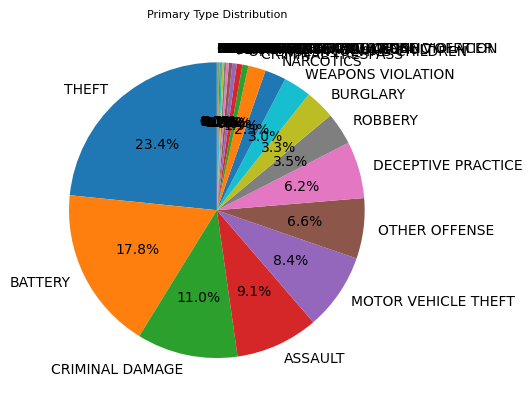

In [10]:
category_counts = df['Primary Type'].value_counts()
category_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Primary Type Distribution', fontsize=8)
plt.ylabel('') # Remove the default 'Category' label on the y-axis
plt.show()

In [19]:
df['Location Description'].unique()

array(['APARTMENT', 'HOTEL / MOTEL', 'STREET', 'SIDEWALK', 'CTA BUS',
       'RESIDENCE', 'BAR OR TAVERN', 'SMALL RETAIL STORE',
       'VEHICLE NON-COMMERCIAL', 'ALLEY', 'COMMERCIAL / BUSINESS OFFICE',
       'PARKING LOT / GARAGE (NON RESIDENTIAL)', 'VACANT LOT / LAND',
       'CONVENIENCE STORE', 'POLICE FACILITY / VEHICLE PARKING LOT',
       'TAVERN / LIQUOR STORE', 'RESIDENCE - GARAGE',
       'RESIDENCE - YARD (FRONT / BACK)', 'RESTAURANT', 'PARK PROPERTY',
       'DRUG STORE', 'RESIDENCE - PORCH / HALLWAY', 'CHA APARTMENT',
       'CTA PLATFORM', 'CTA TRAIN',
       'AIRPORT TERMINAL UPPER LEVEL - NON-SECURE AREA',
       'AIRPORT PARKING LOT', 'HOSPITAL BUILDING / GROUNDS',
       'MEDICAL / DENTAL OFFICE', 'CTA BUS STOP', 'DEPARTMENT STORE',
       'GAS STATION', 'OTHER (SPECIFY)', 'NURSING / RETIREMENT HOME',
       'DRIVEWAY - RESIDENTIAL', 'GOVERNMENT BUILDING / PROPERTY',
       'GROCERY FOOD STORE', 'CHA HALLWAY / STAIRWELL / ELEVATOR',
       'ABANDONED BUILDING', 'WARE

In [ ]:
df['Description'].unique()

array(['TO PROPERTY', 'TO RESIDENCE',
       'AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SERIOUS INJURY',
       'TO VEHICLE', 'SIMPLE', 'DOMESTIC BATTERY SIMPLE',
       'TO CITY OF CHICAGO PROPERTY', 'AUTOMOBILE',
       'HARASSMENT BY TELEPHONE', 'UNLAWFUL POSSESSION - HANDGUN',
       'AGGRAVATED - HANDGUN', '$500 AND UNDER', 'ILLEGAL USE CASH CARD',
       'UNLAWFUL USE / SALE OF AIR RIFLE', 'NON-AGGRAVATED', 'OVER $500',
       'FRAUD OR CONFIDENCE GAME',
       'AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MINOR INJURY',
       'ARMED - KNIFE / CUTTING INSTRUMENT',
       'AGGRAVATED POLICE OFFICER - HANDS, FISTS, FEET, NO INJURY',
       'GUN OFFENDER - ANNUAL REGISTRATION',
       'ARMED WHILE UNDER THE INFLUENCE', 'UNLAWFUL ENTRY',
       'THEFT OF LABOR / SERVICES', 'AGGRAVATED - OTHER DANGEROUS WEAPON',
       'RECKLESS FIREARM DISCHARGE', 'HARASSMENT BY ELECTRONIC MEANS',
       'POSSESS - BARBITURATES',
       'AGGRAVATED - KNIFE / CUTTING INSTRUMENT',
       'LIQUOR LICEN

In [6]:
df['FBI Code'].unique()

array(['14', '26', '04B', '08B', '07', '15', '08A', '06', '11', '02',
       '04A', '03', '05', '18', '22', '17', '01A', '10', '09', '24', '13',
       '20', '19', '16', '12', '01B'], dtype=object)

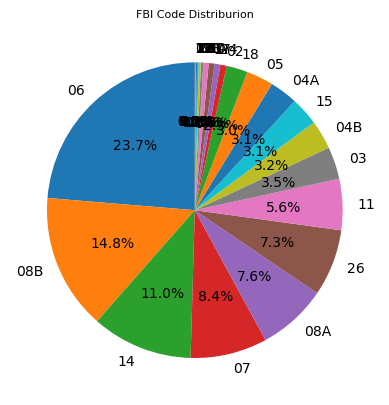

In [11]:
fbi_category_counts = df['FBI Code'].value_counts()
fbi_category_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('FBI Code Distriburion', fontsize=8)
plt.ylabel('') # Remove the default 'Category' label on the y-axis
plt.show()

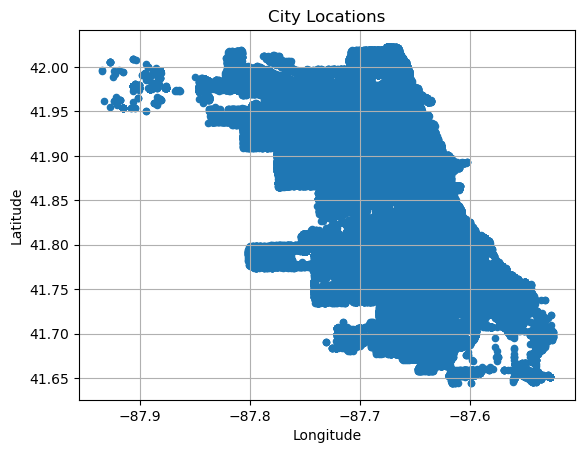

In [55]:
df.plot.scatter(x='Longitude', y='Latitude', title='City Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

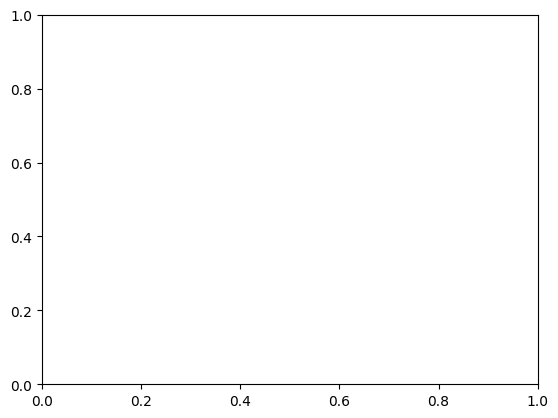

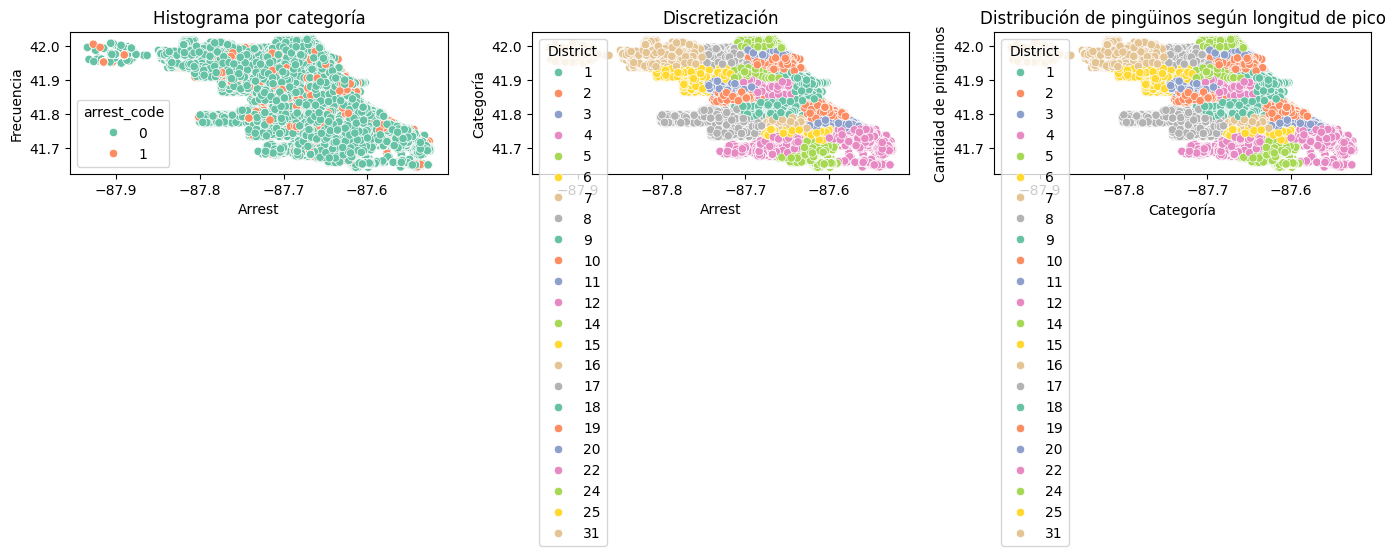

In [ ]:
df['arrest_code'] = df['Arrest'].astype('category').cat.codes

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='arrest_code', palette="Set2", ax=axes[0])
axes[0].set_title(f"Histograma por categoría")
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel("Frecuencia")

sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='District', palette="Set2", ax=axes[1])
axes[1].set_title('Discretización')
axes[1].set_ylabel("Longitude")
axes[1].set_xlabel('Latitude')

sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='District', palette="Set2", ax=axes[2])
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].set_title("Distribución de pingüinos según longitud de pico")

plt.tight_layout()
plt.show()
# Display the plot
plt.show()

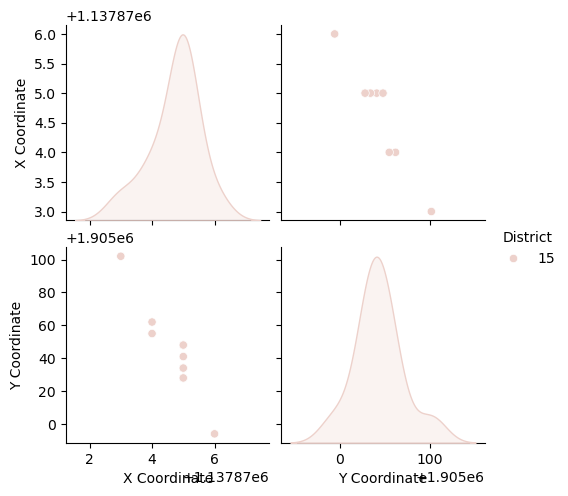

In [ ]:
df_block = df[df['District'] == '008XX N MASSASOIT AVE'][['Block', 'Location Description', 'Ward', 'Community Area', 'District', 'Beat', 'X Coordinate', 'Y Coordinate', 'Location']]
sns.pairplot(data=df_block[['X Coordinate', 'Y Coordinate', 'District']], hue='District')
plt.show()

C:\Users\cristian.aballay\AppData\Local\Temp\ipykernel_18460\2510969681.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Especie', loc='lower right')


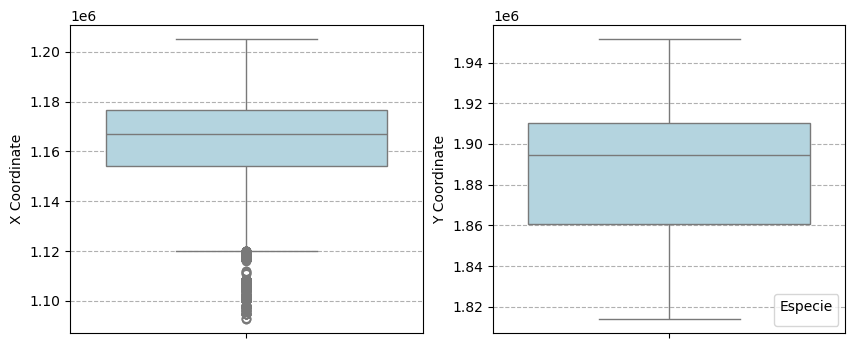

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, y='X Coordinate', color="lightblue", ax=ax[0])
sns.boxplot(data=df, y='Y Coordinate', color="lightblue", ax=ax[1])         # con seaborn-0.13.2

ax[0].grid(axis='y', ls='--')
ax[1].grid(axis='y', ls='--')
plt.legend(title='Especie', loc='lower right')


plt.show()

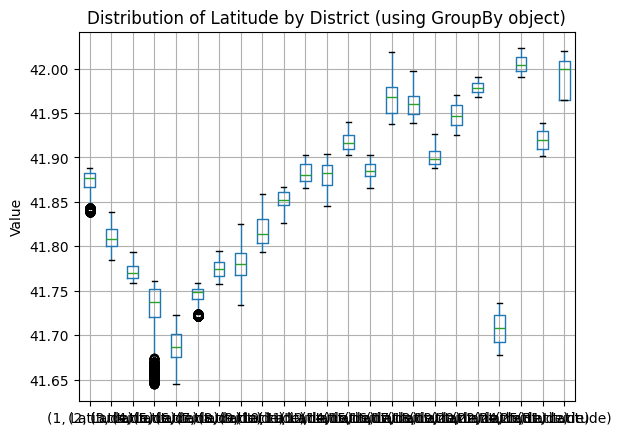

In [3]:
grouped = df.groupby('District')

# Plot the boxplots
# 'column' specifies the data to plot
grouped.boxplot(column='Latitude', subplots=False) 

# Display the plot
plt.title('Distribution of Latitude by District (using GroupBy object)')
plt.ylabel('Value')
plt.show()

C:\Users\cristian.aballay\AppData\Local\Temp\ipykernel_18460\3927453674.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Especie', loc='lower right')


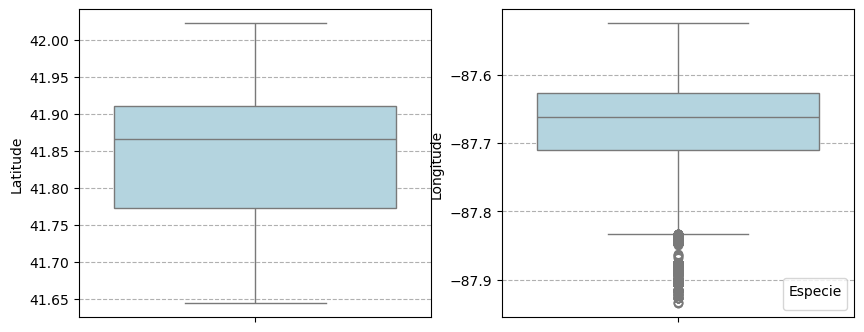

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, y='Latitude', color="lightblue", ax=ax[0])
sns.boxplot(data=df, y='Longitude', color="lightblue", ax=ax[1])         # con seaborn-0.13.2

ax[0].grid(axis='y', ls='--')
ax[1].grid(axis='y', ls='--')
plt.legend(title='Especie', loc='lower right')


plt.show()

### EDA: Analisis de variables categoricas

In [10]:
df.dtypes

ID                        int64
Case Number              object
Date                     object
Block                    object
IUCR                     object
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
Beat                      int64
District                  int64
Ward                      int64
Community Area            int64
FBI Code                 object
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On               object
Latitude                float64
Longitude               float64
Location                 object
dtype: object

In [24]:
df['Date']

0         12/31/2024 11:58:00 PM
1         12/31/2024 11:56:00 PM
2         12/31/2024 11:55:00 PM
3         12/31/2024 11:53:00 PM
4         12/31/2024 11:50:00 PM
                   ...          
258787    01/01/2024 12:00:00 AM
258788    01/01/2024 12:00:00 AM
258789    01/01/2024 12:00:00 AM
258790    01/01/2024 12:00:00 AM
258791    01/01/2024 12:00:00 AM
Name: Date, Length: 258792, dtype: object

In [28]:
df['Primary Type'] = df['Primary Type'].astype('category')
df['Description'] = df['Description'].astype('category')
df['Location Description'] = df['Location Description'].astype('category')
df['FBI Code'] = df['FBI Code'].astype('category')

In [15]:
df.describe(include='category')

,Primary Type,Description,Location Description,FBI Code
count,258792,258792,257703,258792
unique,31,318,128,26
top,THEFT,SIMPLE,STREET,06
freq,60518,31537,69606,61292


Text(0.5, 1.0, 'is_holiday')

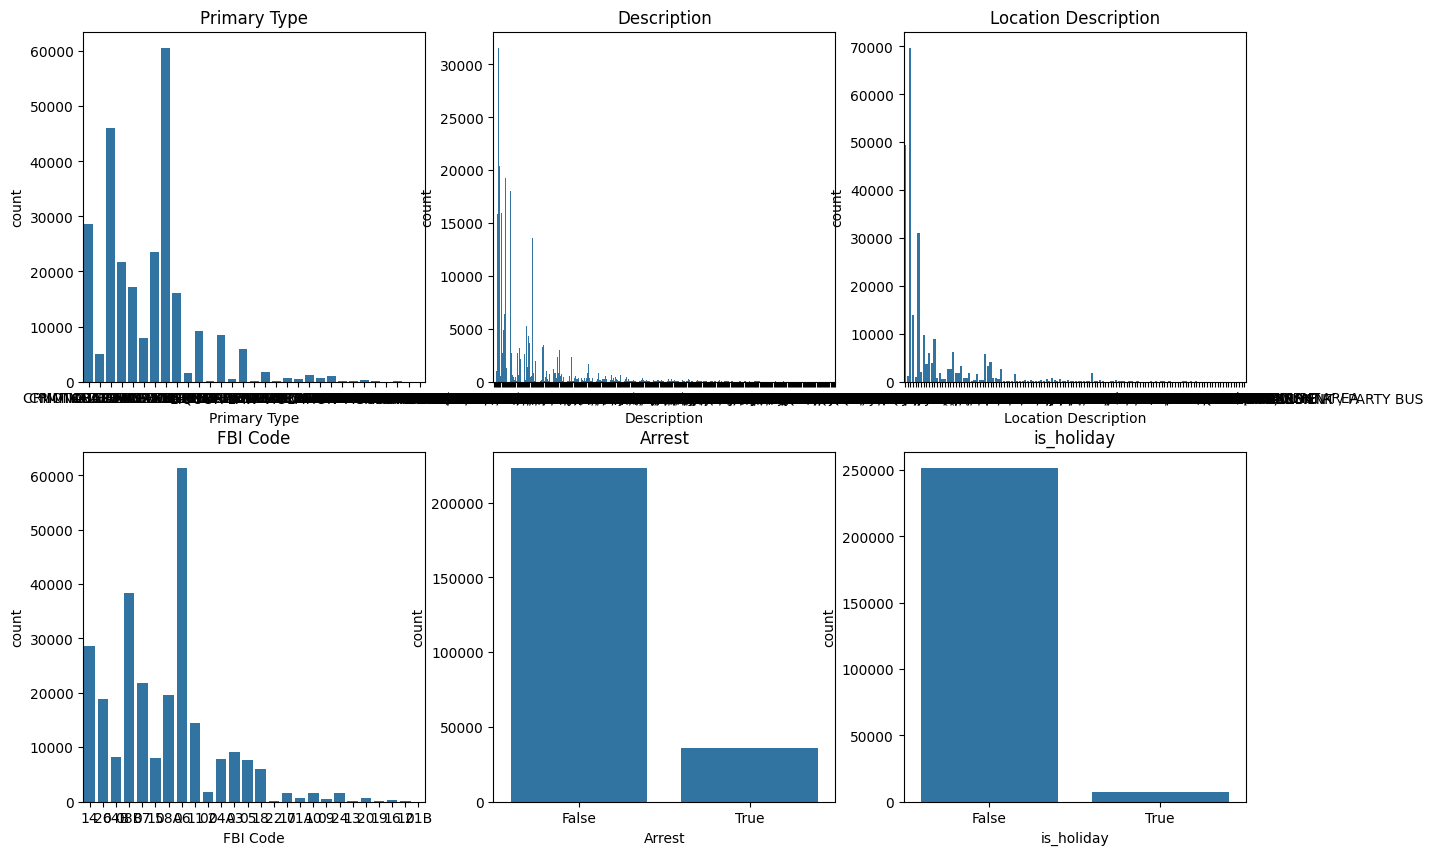

In [54]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

# Gráficos de barras de cada una
sns.countplot(x='Primary Type', data=df, ax=ax[0,0])
sns.countplot(x='Description', data=df, ax=ax[0,1])
sns.countplot(x='Location Description', data=df, ax=ax[0,2])
sns.countplot(x='FBI Code', data=df, ax=ax[1,0])
sns.countplot(x='Arrest', data=df, ax=ax[1,1])
sns.countplot(x='is_holiday', data=df, ax=ax[1,2])
# Títulos
ax[0,0].set_title('Primary Type')
ax[0,1].set_title('Description')
ax[0,2].set_title('Location Description')
ax[1,0].set_title('FBI Code')
ax[1,1].set_title('Arrest')
ax[1,2].set_title('is_holiday')


In [11]:
df["is_holiday"] = df["Date"].apply(lambda d: d in us_holidays)

In [12]:
def get_part_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 22:
        return "Evening"
    else:
        return "Night"
df['date_dt'] = pd.to_datetime(df['Date'])
df['part_of_day'] = df['date_dt'].dt.hour.apply(get_part_of_day)
df['day_week'] = df['date_dt'].dt.day_name()

C:\Users\cristian.aballay\AppData\Local\Temp\ipykernel_23400\546762365.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_dt'] = pd.to_datetime(df['Date'])


In [168]:
def plot(new_var, variable):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    sns.histplot(data=df, x=variable, hue=new_var, multiple="stack", bins=30, palette="Set2", ax=axes[0])
    axes[0].set_title(f"Histograma por categoría ({new_var})")
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel("Frecuencia")

    sns.scatterplot(data=df, x=df.index, y=variable, hue=new_var, palette="Set2", ax=axes[1])
    axes[1].set_title('Discretización')
    axes[1].set_ylabel("Categoría")
    axes[1].set_xlabel(variable)

    sns.countplot(x=new_var, data=df, hue=new_var, palette="Set2", ax=axes[2])
    axes[2].set_xlabel("Categoría")
    axes[2].set_ylabel("Cantidad de pingüinos")
    axes[2].set_title("Distribución de pingüinos según longitud de pico")

    plt.tight_layout()
    plt.show()

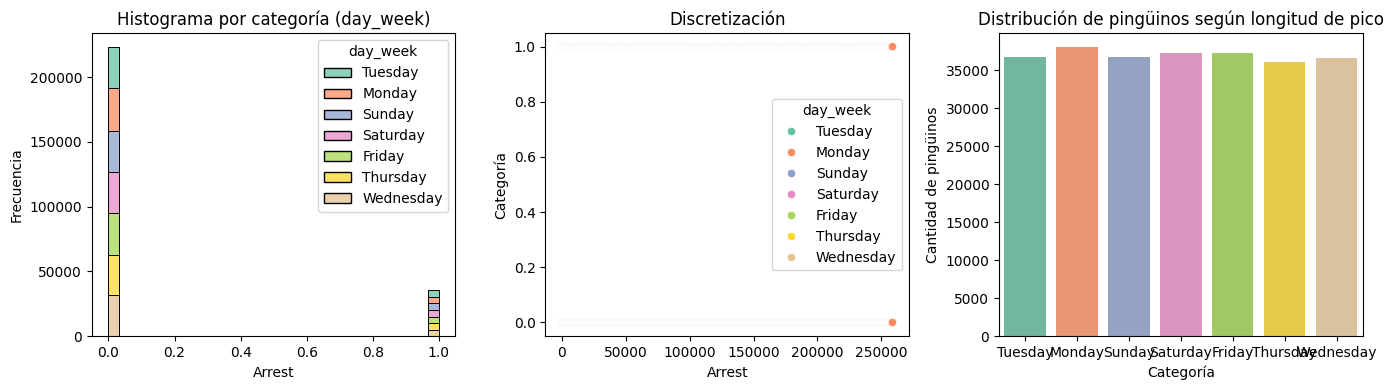

In [23]:
variable = "Arrest"
plot('day_week')

Text(0.5, 1.0, 'day_week')

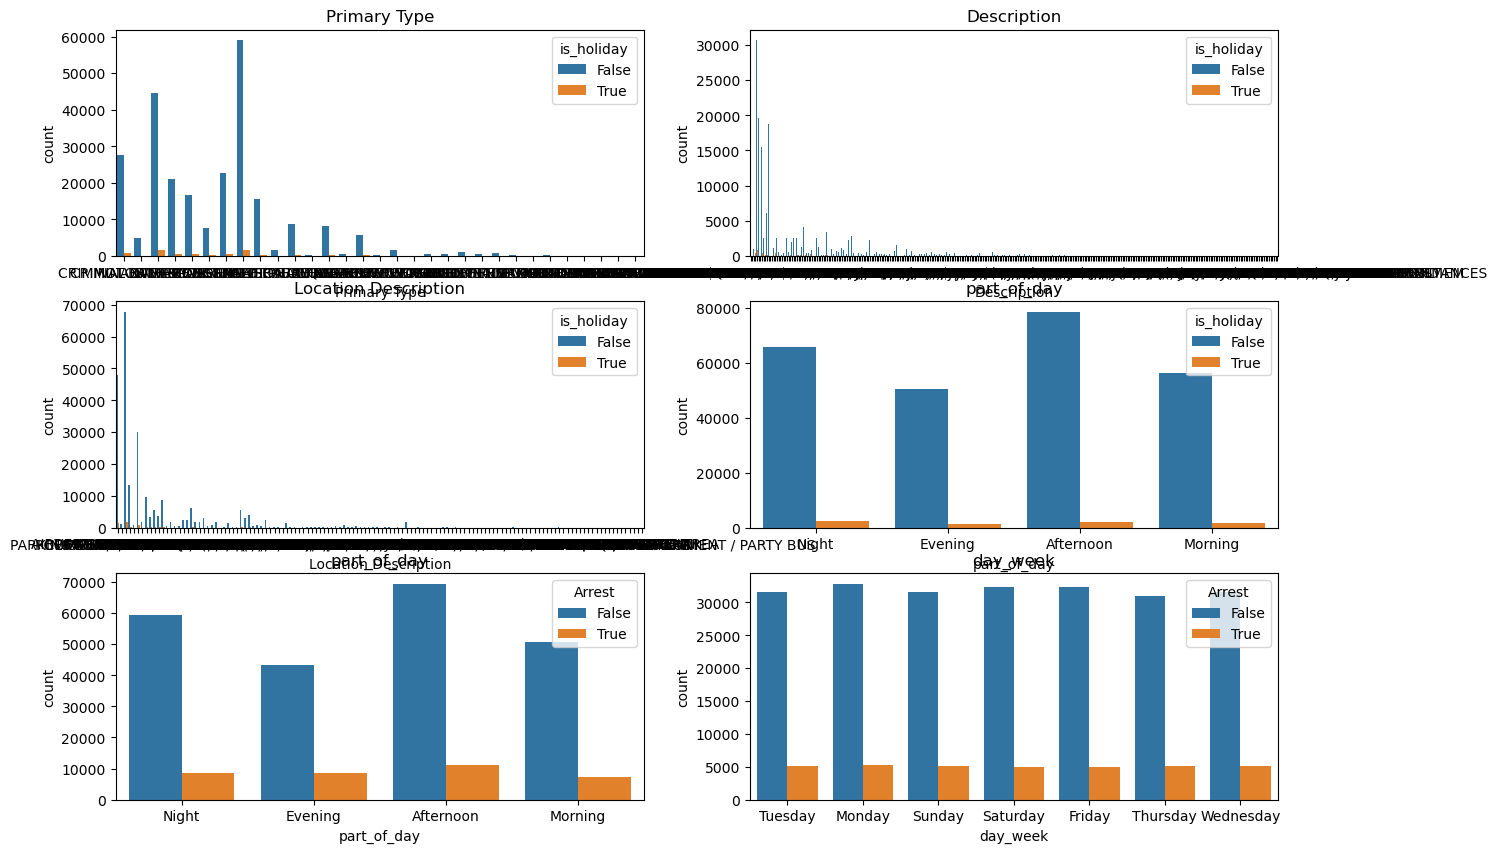

In [9]:
fig, ax = plt.subplots(3, 2, figsize=(15, 10))

# Gráficos de barras de cada una
sns.countplot(x='Primary Type', hue='is_holiday', data=df, ax=ax[0,0])
sns.countplot(x='Description', hue='is_holiday', data=df, ax=ax[0,1])
sns.countplot(x='Location Description', hue='is_holiday', data=df, ax=ax[1,0])
sns.countplot(x='part_of_day', hue='is_holiday', data=df, ax=ax[1,1])
sns.countplot(x='part_of_day', hue='Arrest', data=df, ax=ax[2,0])
sns.countplot(x='day_week', hue='Arrest', data=df, ax=ax[2,1])
# Títulos
ax[0,0].set_title('Primary Type')
ax[0,1].set_title('Description')
ax[1,0].set_title('Location Description')
ax[1,1].set_title('part_of_day')
ax[2,0].set_title('part_of_day')
ax[2,1].set_title('day_week')

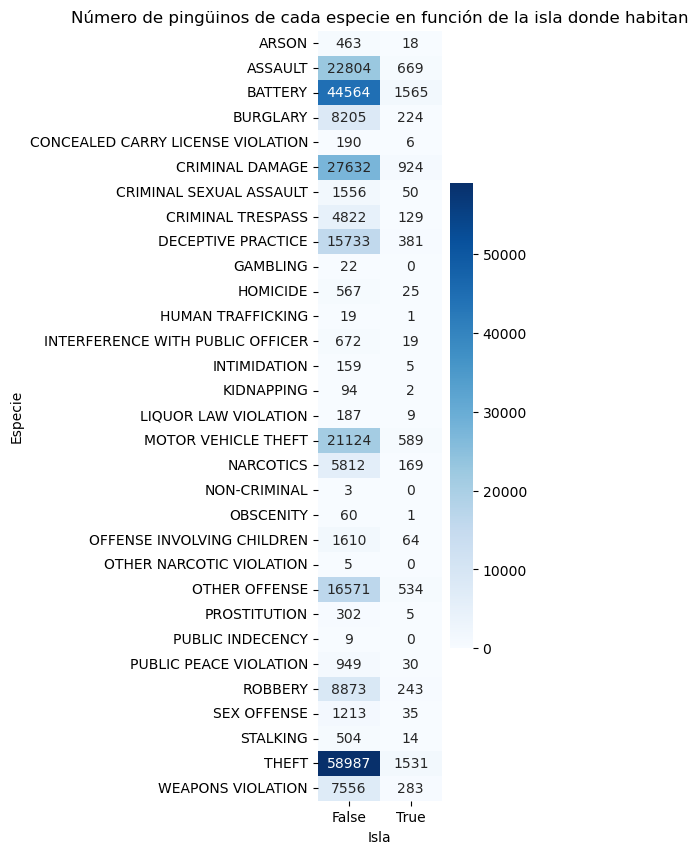

In [30]:
plt.figure(figsize=(2, 10))
cross_tab = pd.crosstab(df['Primary Type'], df['is_holiday'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Número de pingüinos de cada especie en función de la isla donde habitan')
plt.xlabel('Isla')
plt.ylabel('Especie')
plt.show()

In [13]:
df['date_dt'] = pd.to_datetime(df['Date'])
def get_part_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 22:
        return "Evening"
    else:
        return "Night"
df['part_of_day'] = df['date_dt'].dt.hour.apply(get_part_of_day)

C:\Users\cristian.aballay\AppData\Local\Temp\ipykernel_23400\1600650390.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_dt'] = pd.to_datetime(df['Date'])


In [14]:
df['month'] = df['date_dt'].dt.month

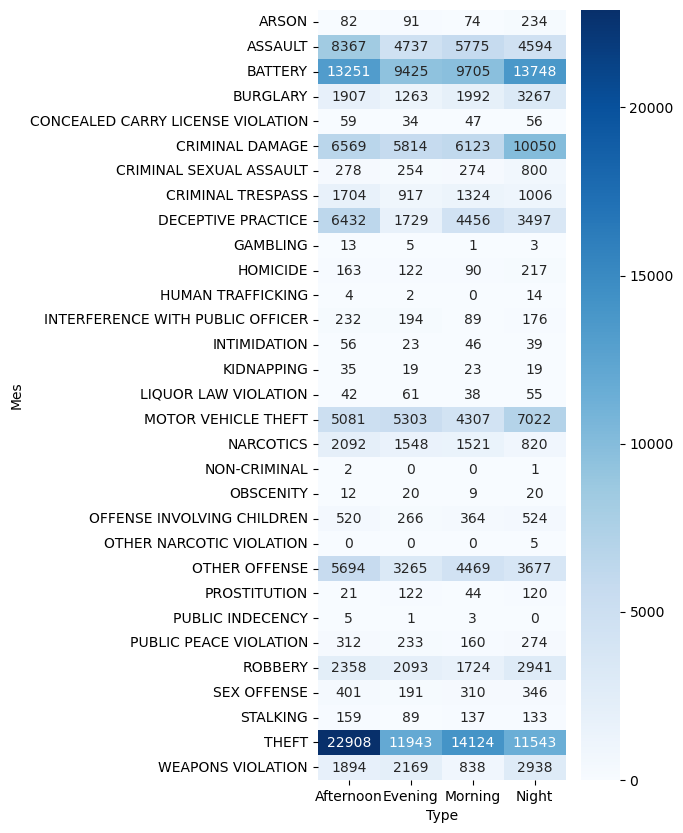

In [64]:
plt.figure(figsize=(4, 10))
cross_tab = pd.crosstab(df['Primary Type'], df['part_of_day'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Type')
plt.ylabel('Mes')
plt.show()

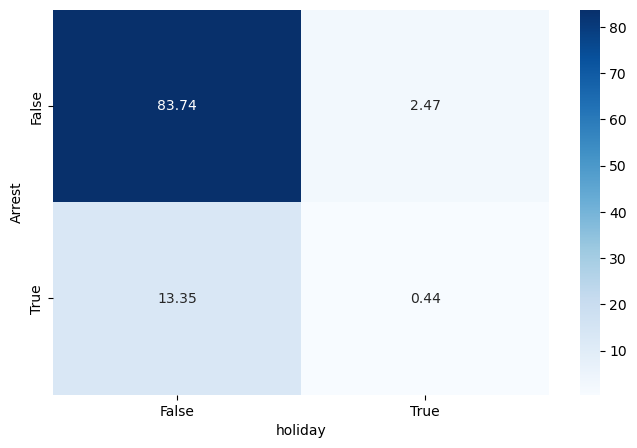

In [35]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(df['Arrest'], df['is_holiday'], normalize='all') * 100
sns.heatmap(cross_tab, annot=True, fmt='.2f', cmap='Blues')
plt.xlabel('holiday')
plt.ylabel('Arrest')
plt.show()

In [ ]:
df[['Arrest', 'Domestic', 'FBI Code', 'Location Description', 'Description', 'Primary Type']]

,FBI Code,Location Description,Description,Primary Type
0,14,APARTMENT,TO PROPERTY,CRIMINAL DAMAGE
1,26,APARTMENT,TO RESIDENCE,CRIMINAL TRESPASS
2,04B,HOTEL / MOTEL,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",BATTERY
3,14,STREET,TO VEHICLE,CRIMINAL DAMAGE
4,08B,SIDEWALK,SIMPLE,BATTERY
...,...,...,...,...
258787,17,RESIDENCE,CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER,OFFENSE INVOLVING CHILDREN
258788,14,RESIDENCE,TO PROPERTY,CRIMINAL DAMAGE
258789,02,OTHER (SPECIFY),NON-AGGRAVATED,CRIMINAL SEXUAL ASSAULT
258790,17,APARTMENT,AGGRAVATED CRIMINAL SEXUAL ABUSE,SEX OFFENSE


In [40]:
pd.crosstab(index=df['Primary Type'],
            columns=df['Arrest'], margins=True)


Arrest,False,True,All
Primary Type,,,
ARSON,437,44,481
ASSAULT,20944,2529,23473
BATTERY,38236,7893,46129
BURGLARY,7968,461,8429
CONCEALED CARRY LICENSE VIOLATION,4,192,196
CRIMINAL DAMAGE,27453,1103,28556
CRIMINAL SEXUAL ASSAULT,1542,64,1606
CRIMINAL TRESPASS,3520,1431,4951
DECEPTIVE PRACTICE,15589,525,16114


### Eliminar duplicados

In [3]:
df.drop_duplicates(subset=['Case Number'], inplace=True)

### Eliminar campos innecesarios:
* 'Year'
* 'Location' --> la misma info esta en latitude y longitude
* 'ID'
* 'Case number' --> sirve para detectar duplicados, despues no interesa
* Update on?

In [178]:
df = df.drop(columns=['Year', 'Location', 'ID', 'Case Number'], axis=1)

### Split de test y train

In [5]:
X = df.drop(columns=['Arrest'], axis=1)

# Definimos la variable target
y = df.loc[:, 'Arrest']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify=y) 

# Verificamos dimensiones
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(207010, 17) (207010,) (51753, 17) (51753,)


### Nuevas Columnas
* Dia feriado
* Dia de la semana (lunes, martes...)
* Parte del dia: medianoche, tarde, mañana

In [154]:
df["is_holiday"] = df["Date"].apply(lambda d: d in us_holidays).astype(int)

In [156]:
def get_part_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 22:
        return "Evening"
    else:
        return "Night"

In [157]:
df['date_dt'] = pd.to_datetime(df['Date'])
df['part_of_day'] = df['date_dt'].dt.hour.apply(get_part_of_day)
df['month'] = df['date_dt'].dt.month
df['day_week'] = df['date_dt'].dt.day_name()

C:\Users\cristian.aballay\AppData\Local\Temp\ipykernel_40784\10727677.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_dt'] = pd.to_datetime(df['Date'])


In [60]:
df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,is_holiday,date_dt,part_of_day,day_week,Location Description_2,X Coordinate_2,Y Coordinate_2,Latitude_2,Longitude_2,month
0,13709672,JJ101940,12/31/2024 11:58:00 PM,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,False,2024-12-31 23:58:00,Night,Tuesday,APARTMENT,1186817.0,1860189.0,41.771470,-87.590742,12
1,13707925,JJ100089,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,...,False,2024-12-31 23:56:00,Night,Tuesday,APARTMENT,1179661.0,1873623.0,41.808501,-87.616563,12
2,13708038,JJ100035,12/31/2024 11:55:00 PM,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,...,False,2024-12-31 23:55:00,Night,Tuesday,HOTEL / MOTEL,1145740.0,1853048.0,41.752749,-87.741498,12
3,13709164,JJ101392,12/31/2024 11:53:00 PM,066XX S GREENWOOD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,False,2024-12-31 23:53:00,Night,Tuesday,STREET,1184362.0,1861188.0,41.774269,-87.599710,12
4,13707823,JJ100020,12/31/2024 11:50:00 PM,012XX N MENARD AVE,0460,BATTERY,SIMPLE,SIDEWALK,False,False,...,False,2024-12-31 23:50:00,Night,Tuesday,SIDEWALK,1137458.0,1907694.0,41.902858,-87.770537,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258787,13699758,JH552112,01/01/2024 12:00:00 AM,113XX S CHAMPLAIN AVE,1751,OFFENSE INVOLVING CHILDREN,CRIMINAL SEXUAL ABUSE BY FAMILY MEMBER,RESIDENCE,False,True,...,True,2024-01-01 00:00:00,Night,Monday,RESIDENCE,1182606.0,1829881.0,41.688400,-87.607115,1
258788,13325271,JH100317,01/01/2024 12:00:00 AM,013XX S CLAREMONT AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,...,True,2024-01-01 00:00:00,Night,Monday,RESIDENCE,1160805.0,1893884.0,41.864510,-87.685162,1
258789,13431182,JH227698,01/01/2024 12:00:00 AM,050XX S MICHIGAN AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,OTHER (SPECIFY),True,False,...,True,2024-01-01 00:00:00,Night,Monday,OTHER (SPECIFY),1178008.0,1871738.0,41.803366,-87.622683,1
258790,13326749,JH102278,01/01/2024 12:00:00 AM,033XX N HARLEM AVE,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,APARTMENT,False,False,...,True,2024-01-01 00:00:00,Night,Monday,APARTMENT,1127494.0,1921288.0,41.940335,-87.806831,1


### Escalares

In [15]:
scaler = MinMaxScaler()
df[['x_coordinate_scaled', 'y_coordinate_scaled', 'latitude_scaled', 'longitude_scaled']] = scaler.fit_transform(df[['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude']])

In [16]:
df["latitude_cat"] = pd.cut(df['latitude_scaled'], bins=3, labels=["south", "center", "north"])
df["longitude_cat"] = pd.cut(df['longitude_scaled'], bins=3, labels=["west", "center", "east"])
df["y_coordinate_cat"] = pd.cut(df['y_coordinate_scaled'], bins=3, labels=["south", "center", "north"])
df["x_coordinate_cat"] = pd.cut(df['x_coordinate_scaled'], bins=3, labels=["west", "center", "east"])

### Transformacion variables Categoricas a Numericas
* Block: 28693 || Missing: 0 || Type: object || ['014XX E 68TH ST' '047XX S DR MARTIN LUTHER KING JR DR','077XX S CICERO AVE' '066XX S GREENWOOD AVE' '012XX N MENARD AVE']
* IUCR: 340 || Missing: 0 || Type: object || ['1310' '1365' '0498' '1320' '0460']
* Primary Type: 31 || Missing: 0 || Type: object || ['CRIMINAL DAMAGE' 'CRIMINAL TRESPASS' 'BATTERY' 'MOTOR VEHICLE THEFT','OTHER OFFENSE']
* Description: 318 || Missing: 0 || Type: object || ['TO PROPERTY' 'TO RESIDENCE','AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SERIOUS INJURY' 'TO VEHICLE','SIMPLE']
* Location Description: 129 || Missing: 1089 || Type: object || ['APARTMENT' 'HOTEL / MOTEL' 'STREET' 'SIDEWALK' 'CTA BUS']
* Arrest: 2 || Missing: 0 || Type: bool || [False  True]
* Domestic: 2 || Missing: 0 || Type: bool || [False  True]
* Beat: 275 || Missing: 0 || Type: int64 || [ 332  223  834  321 2531]
* District: 23 || Missing: 0 || Type: int64 || [ 3  2  8 25 12]
* Ward: 50 || Missing: 0 || Type: int64 || [ 5  3 18 20 29]
* Community Area: 77 || Missing: 0 || Type: int64 || [43 38 70 42 25]
* FBI Code: 26 || Missing: 0 || Type: object || ['14' '26' '04B' '08B' '07']

In [17]:
df['arrest_code'] = df['Arrest'].astype(int)
df['domestic_code'] = df['Domestic'].astype(int)

In [18]:
df_categorical = df[['Primary Type', 'Description', 'Location Description', 'FBI Code', 'is_holiday', 'part_of_day', 'day_week', 'Block', 'IUCR', 'District', 'Ward', 'Community Area', 'month', 'latitude_cat', 'longitude_cat', 'y_coordinate_cat', 'x_coordinate_cat', 'domestic_code', 'arrest_code']]

In [26]:
mca = prince.MCA(n_components=5)
mca = mca.fit(df_categorical)


MemoryError: Unable to allocate 57.2 GiB for an array with shape (258725, 29691) and data type float64

In [ ]:
mca_result = mca.transform(df_categorical)
mca_result

,0,1
0,0.278393,-0.117582
1,-0.468327,0.057875
2,-0.226473,0.224796
3,0.631465,-0.217748
4,-0.116787,0.248460
...,...,...
258787,-0.847542,-0.122542
258788,0.282031,-0.115628
258789,-0.285153,0.111116
258790,-1.350680,-0.566576


In [ ]:
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.477,0.66%,0.66%
1,0.470,0.65%,1.30%
2,0.460,0.63%,1.93%
3,0.446,0.61%,2.55%
4,0.441,0.61%,3.15%


In [42]:
#mca.row_coordinates(df_categorical).head()
#mca.row_contributions_.head().style.format('{:.0%}')
mca.column_contributions_.head().style.format('{:.0%}')

,0,1,2,3,4
Primary Type__ARSON,0%,0%,0%,0%,0%
Primary Type__ASSAULT,1%,0%,2%,0%,1%
Primary Type__BATTERY,2%,0%,4%,0%,3%
Primary Type__BURGLARY,1%,0%,0%,4%,0%
Primary Type__CONCEALED CARRY LICENSE VIOLATION,0%,0%,0%,0%,0%


#### Estimación y representación gráfica de los coeficientes de correlación por pares de Pearson

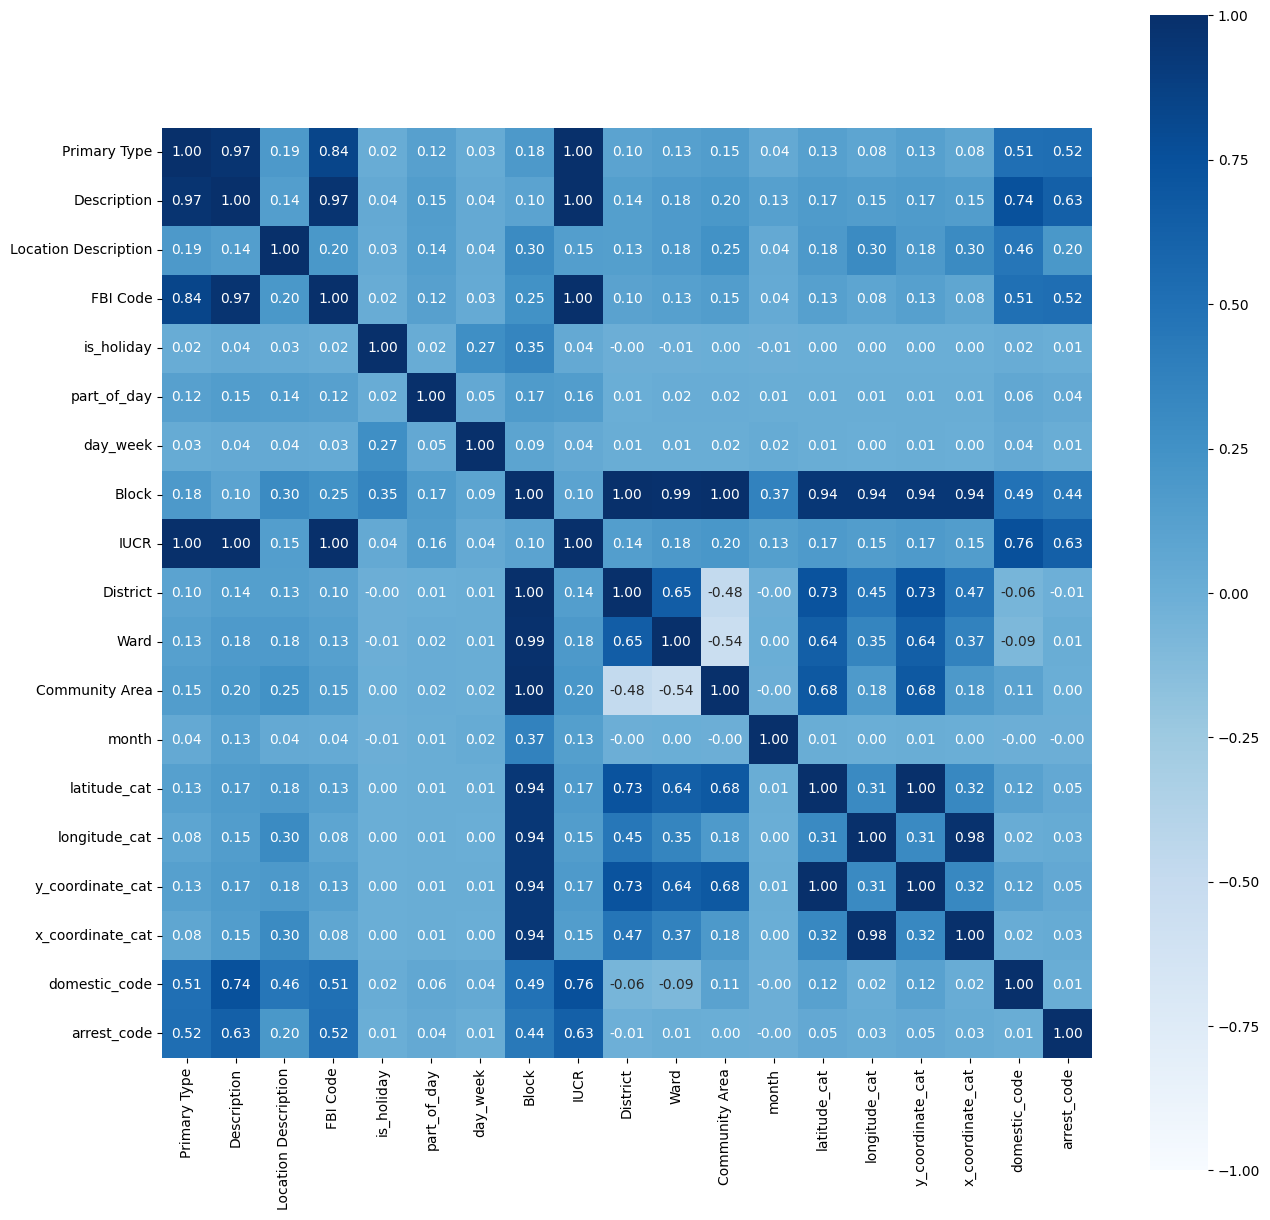

In [27]:
correlation_matrix = associations(df_categorical, compute_only=False, figsize=(15,15), cmap = "Blues")

In [ ]:
correlation_matrix = associations(data, compute_only=False, figsize=(15,15))

,Primary Type,Description,Location Description,FBI Code,is_holiday,part_of_day,day_week
Primary Type,1.000000,0.965727,0.185909,0.843060,0.023099,0.119556,0.030852
Description,0.965727,1.000000,0.144567,0.968164,0.043382,0.153614,0.041571
Location Description,0.185909,0.144567,1.000000,0.200693,0.032538,0.141039,0.044437
FBI Code,0.843060,0.968164,0.200693,1.000000,0.022774,0.121928,0.031302
is_holiday,0.023099,0.043382,0.032538,0.022774,1.000000,0.019293,0.269108
part_of_day,0.119556,0.153614,0.141039,0.121928,0.019293,1.000000,0.048077
day_week,0.030852,0.041571,0.044437,0.031302,0.269108,0.048077,1.000000


#### Estimación de la asociación V de Cramer entre variables nominales

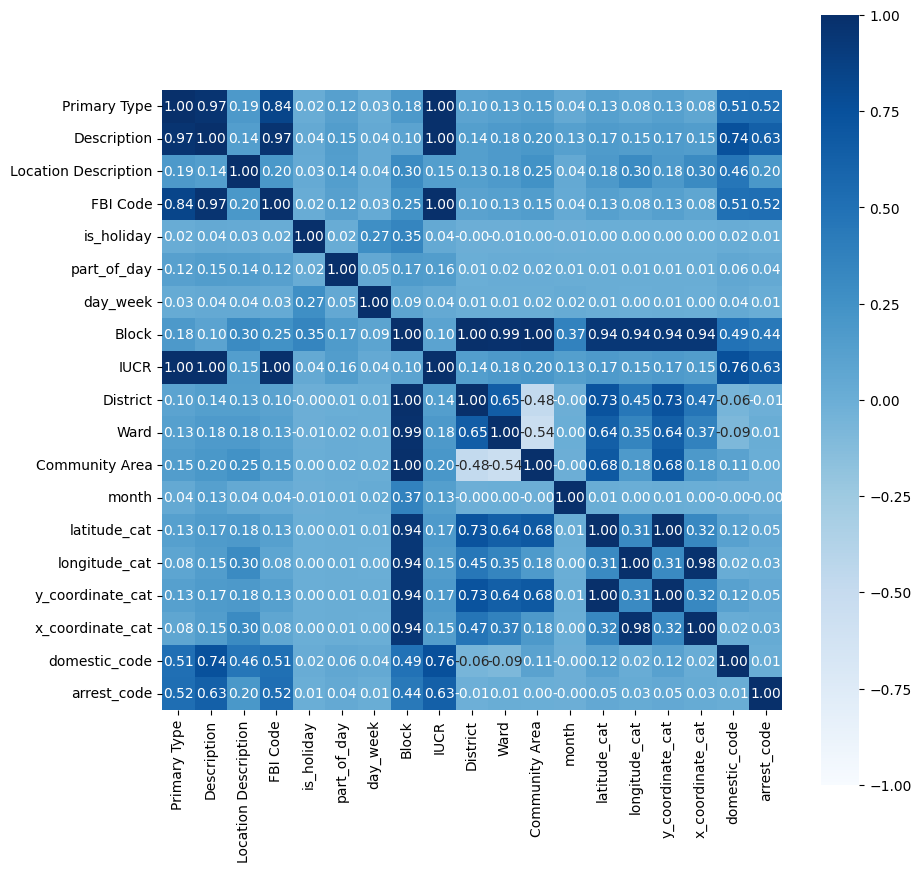

In [28]:
fig, ax = plt.subplots(figsize = (10, 10))
# Estimar y generar el gráfico de asociación V de Cramer 
cramers_v = associations(df_categorical, 
             nom_nom_assoc = 'cramer', 
             ax = ax, 
             cmap = "Blues")

### Codificacion

In [19]:
df['arrest_code'] = df['Arrest'].astype(int)
df['domestic_code'] = df['Domestic'].astype(int)

In [20]:
encoder = ce.BinaryEncoder(cols=['Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'part_of_day', 'month', 'day_week', 'latitude_cat', 'longitude_cat', 'y_coordinate_cat', 'x_coordinate_cat'], return_df=True)

# Fit and transform the data
df_encoded = encoder.fit_transform(df)

In [21]:
df_encoded['domestic'] = df['Domestic'].astype(int)
df_encoded['is_holiday'] = df['is_holiday'].astype(int)

In [77]:
encoder = ce.BinaryEncoder(cols=['Location', 'is_holiday', 'part_of_day', 'day_week', 'month'], return_df=True)
df_encoded = encoder.fit_transform(df_encoded)

In [ ]:
df['arrest_code'] = df['Arrest'].astype(int)

In [22]:
df_encoded.columns

Index(['Date', 'Block_0', 'Block_1', 'Block_2', 'Block_3', 'Block_4',
       'Block_5', 'Block_6', 'Block_7', 'Block_8',
       ...
       'latitude_cat_1', 'longitude_cat_0', 'longitude_cat_1',
       'y_coordinate_cat_0', 'y_coordinate_cat_1', 'x_coordinate_cat_0',
       'x_coordinate_cat_1', 'arrest_code', 'domestic_code', 'domestic'],
      dtype='object', length=112)

In [24]:
df_categorical = df_encoded.drop(columns=['Date', 'date_dt', 'Arrest', 'Domestic', 'X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude'], axis=1)

#### CHI Cuadrado

In [ ]:
X_train_cat = df_encoded[['Primary Type_0', 'Primary Type_1', 'Primary Type_2', 'Primary Type_3', 'Primary Type_4', 'Location Description_0', 'Location Description_1', 'Location Description_2', 'Location Description_3', 'Location Description_4', 'Location Description_5', 'Location Description_6', 'Location Description_7', 'is_holiday', 'part_of_day_0', 'part_of_day_1', 'part_of_day_2', 'day_week_0', 'day_week_1', 'day_week_2', 'month_0', 'month_1', 'month_2', 'month_3', 'latitude_cat_0', 'latitude_cat_1', 'longitude_cat_0', 'longitude_cat_1', 'y_coordinate_cat_0', 'y_coordinate_cat_1', 'x_coordinate_cat_0', 'x_coordinate_cat_1', 'domestic_code']]
y_train_encoded = df_encoded[['arrest_code']]

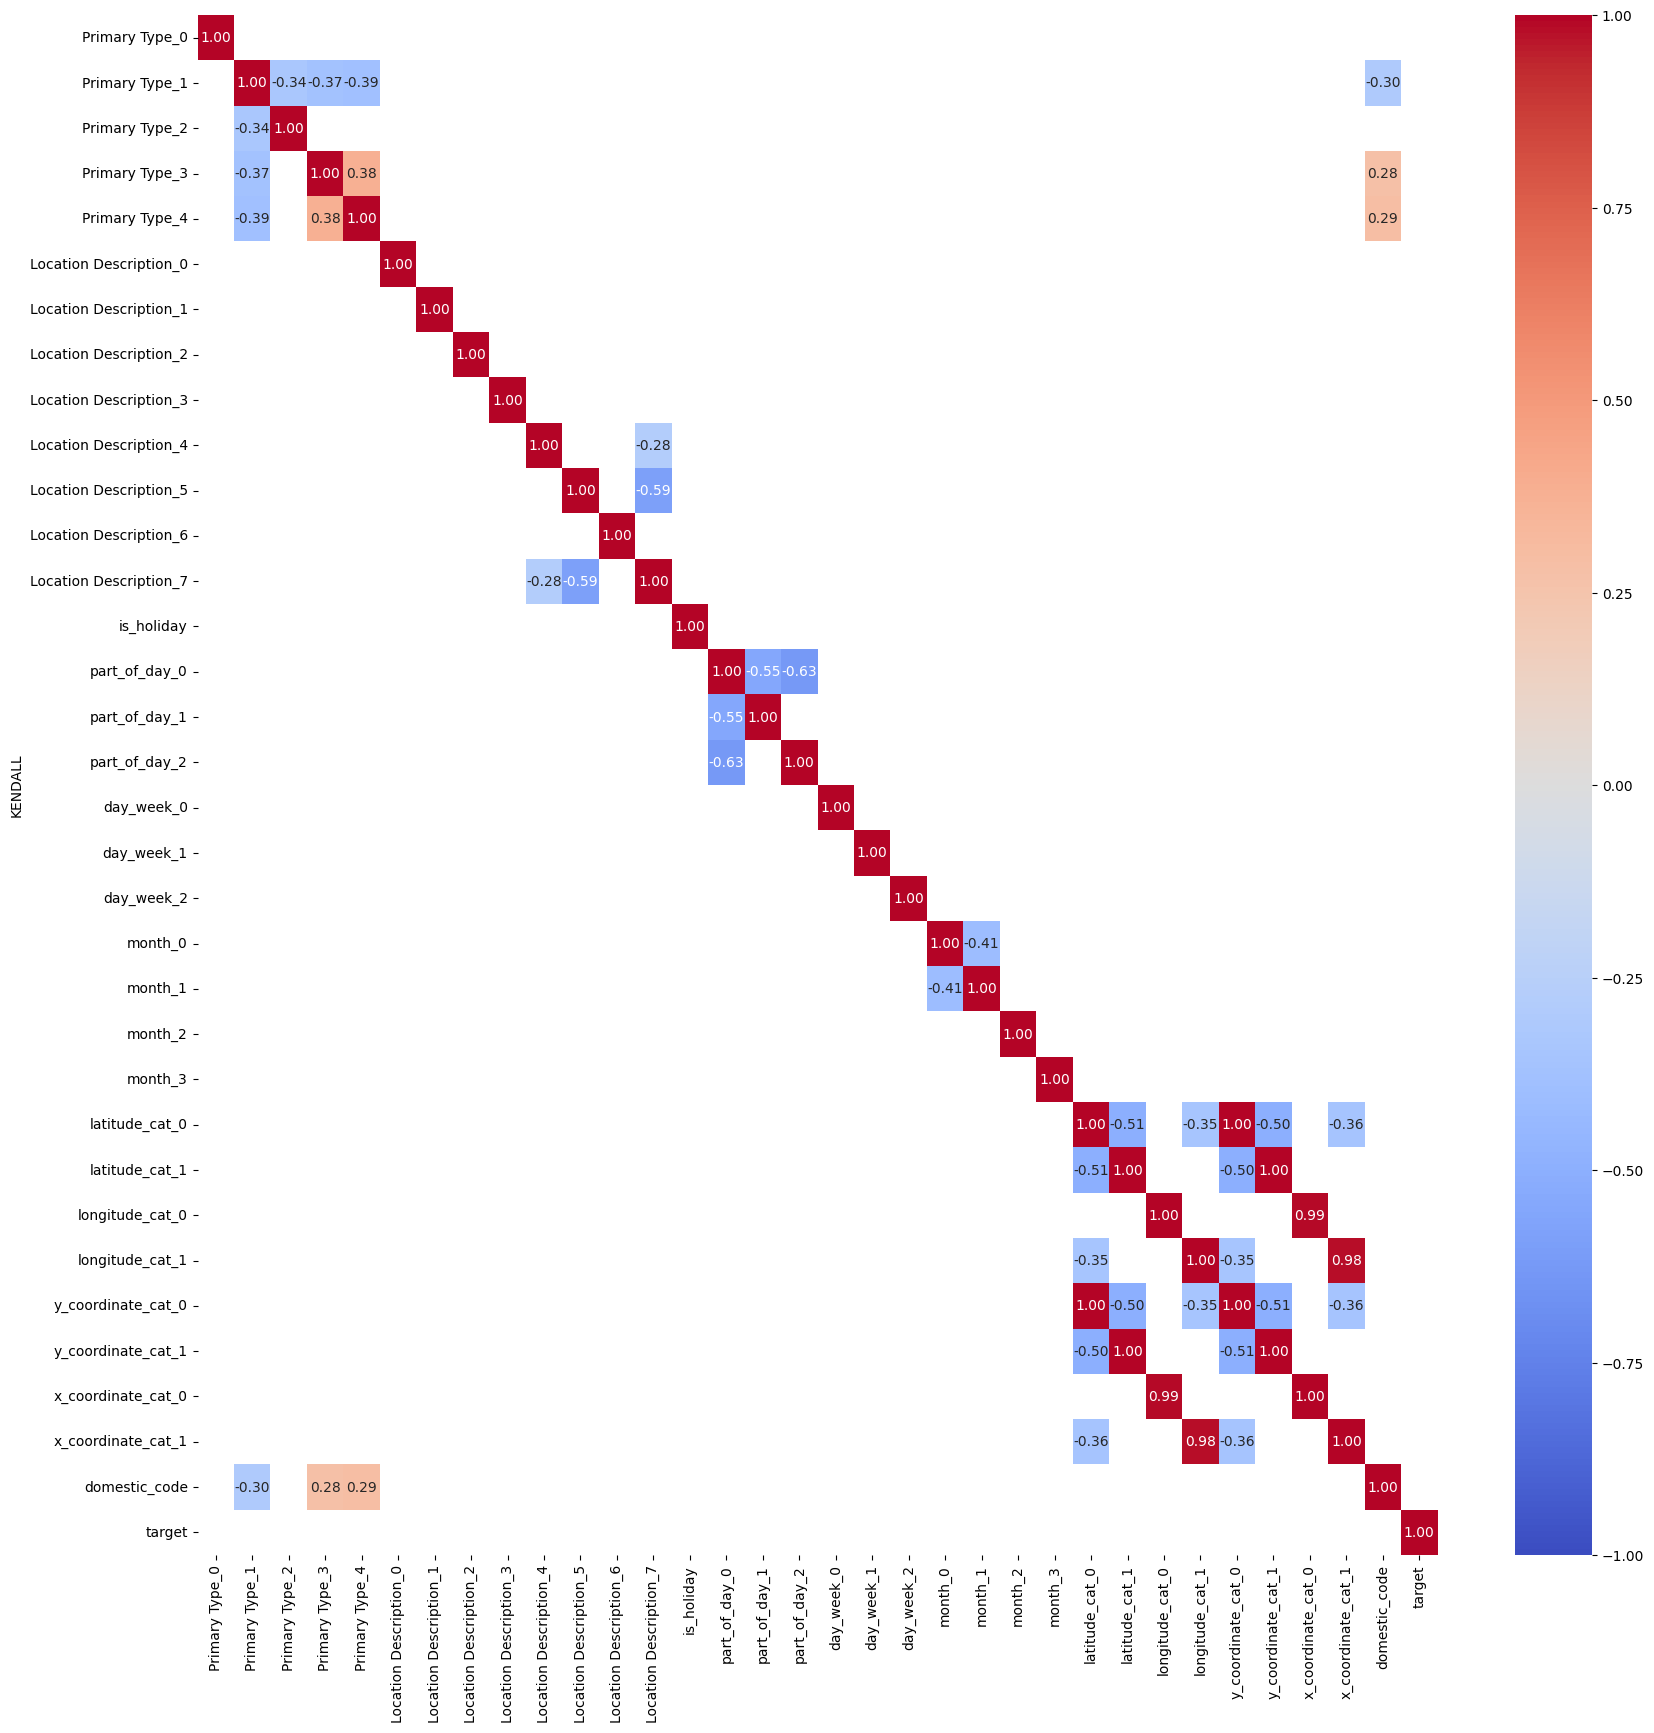

In [263]:
datos_train_corr = X_train_cat.copy()
datos_train_corr['target'] = y_train_encoded.copy()


umbral = 0.25
mask_for_heatmap = (datos_train_corr.corr(method='kendall').abs() < umbral)
plt.figure(figsize=(20,20))
sns.heatmap(
    datos_train_corr.corr(method='kendall'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=mask_for_heatmap)
plt.ylabel('KENDALL')
plt.show()

In [99]:
# Chi-Square (categóricas, fit en train, transformar ambos)
selector_chi2 = SelectKBest(score_func=chi2, k=30)
X_train_cat_best = selector_chi2.fit_transform(X_train_cat, y_train_encoded)
selected_indices = selector_chi2.get_support()
selected_features = X_train_cat.columns[selected_indices]
scores = selector_chi2.scores_[selected_indices]
print("\nCaracterísticas seleccionadas (Chi-Square):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")


Características seleccionadas (Chi-Square):
Primary Type_0: 2013.0027
Primary Type_1: 315.2187
Primary Type_2: 4251.5075
Primary Type_3: 9542.7249
Primary Type_4: 88.4220
Location_0: 45.7859
Location_1: 97.5716
Location_2: 142.8317
Location_3: 97.5878
Location_4: 39.5026
Location_5: 17.8235
Location_6: 9.9774
Location_7: 16.6396
Location_8: 2.1283
Location_9: 0.0274
Location_10: 1.2947
Location_11: 2.1699
Location_12: 1.1145
is_holiday_0: 12.3553
part_of_day_0: 97.5556
part_of_day_1: 145.1214
part_of_day_2: 19.4520
day_week_0: 1.9489
day_week_1: 1.5032
day_week_2: 0.6248
month_0: 1.7007
month_1: 2.5364
month_2: 1.1665
month_3: 5.0881
Domestic_0: 42.2157


In [101]:
# Información mutua (todas, fit en train, transformar ambos)
selector_mi = SelectKBest(score_func=mutual_info_classif, k=10) # también se puede usar mutual_info_regression para problemas de ese tipo
X_train_best = selector_mi.fit_transform(X_train_cat, y_train_encoded) # todos los tipos de features
selected_indices = selector_mi.get_support()
selected_features = X_train_cat.columns[selected_indices]
scores = selector_mi.scores_[selected_indices]
print("\nCaracterísticas seleccionadas (Inf. mutua):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")

X_test_best = selector_mi.transform(X_test_final)

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Características seleccionadas (Inf. mutua):
Primary Type_3: 0.0468
Primary Type_4: 0.0392
Location_12: 0.0325
part_of_day_1: 0.0335
part_of_day_2: 0.0376
day_week_0: 0.0368
day_week_1: 0.0357
day_week_2: 0.0390
month_2: 0.0326
month_3: 0.0326


NameError: name 'X_test_final' is not defined

In [98]:
X_train_cat

,Primary Type_0,Primary Type_1,Primary Type_2,Primary Type_3,Primary Type_4,Location_0,Location_1,Location_2,Location_3,Location_4,...,part_of_day_1,part_of_day_2,day_week_0,day_week_1,day_week_2,month_0,month_1,month_2,month_3,Domestic_0
0,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
1,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,1
2,0,0,0,1,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,1
3,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
4,0,0,0,1,1,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258787,1,0,0,0,1,1,1,1,1,0,...,0,1,0,1,0,1,1,0,0,1
258788,0,0,0,0,1,1,1,1,1,0,...,0,1,0,1,0,1,1,0,0,0
258789,0,1,0,1,0,0,1,0,1,0,...,0,1,0,1,0,1,1,0,0,0
258790,1,0,1,0,1,1,1,1,1,0,...,0,1,0,1,0,1,1,0,0,0


#### PCA

In [ ]:
df_categorical = df_categorical.drop(columns=['arrest_code'], axis=1)

In [ ]:
pca = PCA() # PCA con 2 componentes principales
pca.fit(df_categorical)
df_component = pca.fit_transform(df_categorical)

explained_var = pca.explained_variance_ratio_

# varianza acumulada
cumulative_var = np.cumsum(explained_var)

n_components = len(explained_var)
componentes = np.arange(1, n_components + 1)

print("\nVarianza de cada componente:", pca.explained_variance_)        # Autovalores
print("\nVarianza explicada (%):", pca.explained_variance_ratio_ * 100) # varianza explicada
print("\nComponentes principales:\n", pca.components_)

KeyError: "['arrest_code'] not found in axis"

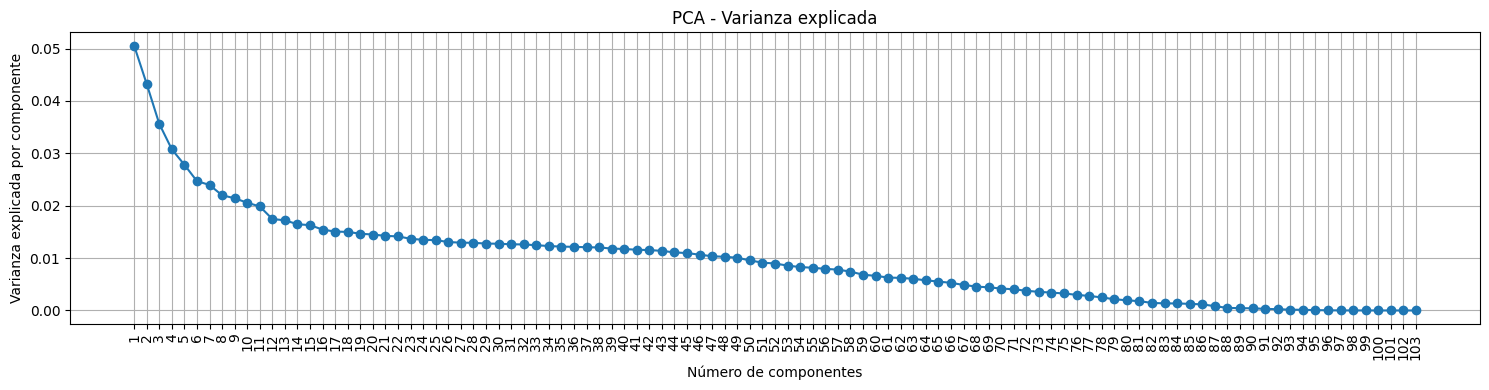

Varianza explicada por cada componente:
[5.05585188e-02 4.32438173e-02 3.56331416e-02 3.07596189e-02
 2.78190624e-02 2.46880326e-02 2.39582463e-02 2.19893389e-02
 2.14200860e-02 2.05642920e-02 1.98551710e-02 1.74514197e-02
 1.72116257e-02 1.64570144e-02 1.62893588e-02 1.54319482e-02
 1.50577147e-02 1.49962194e-02 1.46497319e-02 1.44969970e-02
 1.42393797e-02 1.41390728e-02 1.36855208e-02 1.34813372e-02
 1.34300967e-02 1.30635771e-02 1.29427604e-02 1.29177203e-02
 1.27680044e-02 1.27426952e-02 1.26364955e-02 1.26018059e-02
 1.24570790e-02 1.22994550e-02 1.21909369e-02 1.21480641e-02
 1.20697870e-02 1.20308797e-02 1.18175898e-02 1.17367832e-02
 1.15901276e-02 1.15292323e-02 1.13769781e-02 1.10796062e-02
 1.09573803e-02 1.06484571e-02 1.03489483e-02 1.02492343e-02
 1.00652044e-02 9.54920610e-03 9.13216062e-03 8.96511012e-03
 8.56139952e-03 8.28932100e-03 8.15366996e-03 7.94424955e-03
 7.79742345e-03 7.41456881e-03 6.83225847e-03 6.60772430e-03
 6.28425131e-03 6.21901804e-03 6.05001357e-03

In [46]:
# varianza explicada por cada componente
plt.figure(figsize=(15, 4))
plt.plot(componentes, explained_var, marker='o')
plt.xticks(componentes, rotation=90)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada por componente')
plt.title('PCA - Varianza explicada')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Varianza explicada por cada componente:\n{explained_var}')

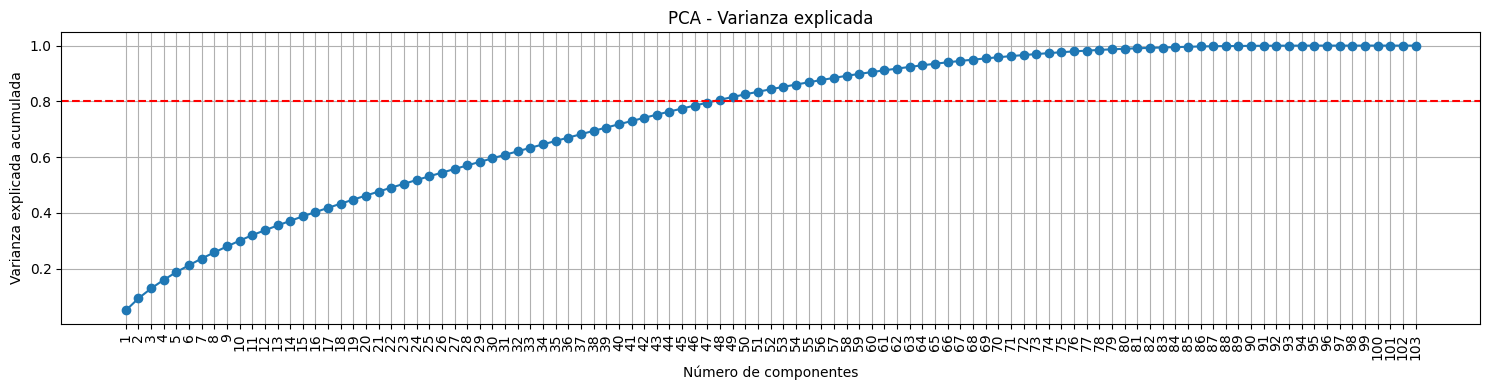

Varianza explicada acumulada:
[0.05055852 0.09380234 0.12943548 0.1601951  0.18801416 0.21270219
 0.23666044 0.25864978 0.28006986 0.30063415 0.32048933 0.33794075
 0.35515237 0.37160939 0.38789874 0.40333069 0.41838841 0.43338463
 0.44803436 0.46253136 0.47677074 0.49090981 0.50459533 0.51807667
 0.53150676 0.54457034 0.5575131  0.57043082 0.58319882 0.59594152
 0.60857802 0.62117982 0.6336369  0.64593636 0.65812729 0.67027536
 0.68234514 0.69437602 0.70619361 0.7179304  0.72952052 0.74104976
 0.75242673 0.76350634 0.77446372 0.78511218 0.79546113 0.80571036
 0.81577556 0.82532477 0.83445693 0.84342204 0.85198344 0.86027276
 0.86842643 0.87637068 0.88416811 0.89158267 0.89841493 0.90502266
 0.91130691 0.91752593 0.92357594 0.92932945 0.93484815 0.94012396
 0.94500064 0.94956799 0.95398438 0.95817381 0.9622172  0.96598187
 0.96953351 0.9729486  0.97619132 0.97917732 0.98195204 0.98444478
 0.98659175 0.98853306 0.99030571 0.99174747 0.99310468 0.99444299
 0.99570955 0.9968729  0.9977003

In [44]:
plt.figure(figsize=(15, 4))
plt.plot(componentes, cumulative_var, marker='o')
plt.xticks(componentes, rotation=90)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada')
plt.grid(True)
plt.axhline(y=0.8, color='red', linestyle='--', label='80% de varianza')
plt.tight_layout()
plt.show()

print(f'Varianza explicada acumulada:\n{cumulative_var}')

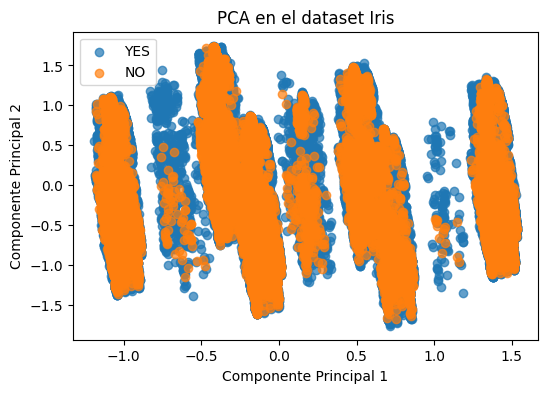

In [277]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_cat)

plt.figure(figsize=(6, 4))
for i, target_name in enumerate(["YES", "NO"]):
    plt.scatter(X_train_pca[y_train_encoded['arrest_code'] == i, 0], X_train_pca[y_train_encoded['arrest_code'] == i, 1], label=target_name, alpha=0.7)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.title("PCA en el dataset Iris")
plt.show()

In [108]:
X_train_pca

array([[ 0.10130979, -0.12128997],
       [-0.15635093, -0.17686501],
       [-0.65665019, -0.21136173],
       ...,
       [ 0.36752176, -0.07965401],
       [-0.61404885, -0.08634908],
       [ 0.20735757, -0.00495262]], shape=(258792, 2))

### Normalizacion

In [164]:
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df[['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude']]), columns=['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude'])
print("Normalizado:\n", df_normalized.head())

Normalizado:
    X Coordinate  Y Coordinate  Latitude  Longitude
0      0.837275      0.336434  0.335700   0.838523
1      0.773650      0.434068  0.433676   0.775551
2      0.472055      0.284536  0.286167   0.470859
3      0.815447      0.343695  0.343106   0.816652
4      0.398419      0.681684  0.683326   0.400039


In [165]:
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df[['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude']]), columns=['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude'])
print("\nEstandarizado:\n", df_standardized.head())


Estandarizado:
    X Coordinate  Y Coordinate  Latitude  Longitude
0      1.332562     -0.873459 -0.877046   1.328864
1      0.889758     -0.447501 -0.450051   0.890089
2     -1.209228     -1.099883 -1.092921  -1.232957
3      1.180649     -0.841784 -0.844770   1.176471
4     -1.721707      0.632805  0.637967  -1.726421


In [210]:
scaler = MinMaxScaler()
df[['x_coordinate_scaled', 'y_coordinate_scaled', 'latitude_scaled', 'longitude_scaled']] = scaler.fit_transform(df[['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude']])

In [211]:
df[['x_coordinate_scaled', 'y_coordinate_scaled', 'latitude_scaled', 'longitude_scaled']]

,x_coordinate_scaled,y_coordinate_scaled,latitude_scaled,longitude_scaled
0,0.837275,0.336434,0.335700,0.838523
1,0.773650,0.434068,0.433676,0.775551
2,0.472055,0.284536,0.286167,0.470859
3,0.815447,0.343695,0.343106,0.816652
4,0.398419,0.681684,0.683326,0.400039
...,...,...,...,...
258787,0.799835,0.116166,0.115914,0.798592
258788,0.606000,0.581318,0.581865,0.608252
258789,0.758953,0.420368,0.420090,0.760626
258790,0.309828,0.780481,0.782483,0.311525


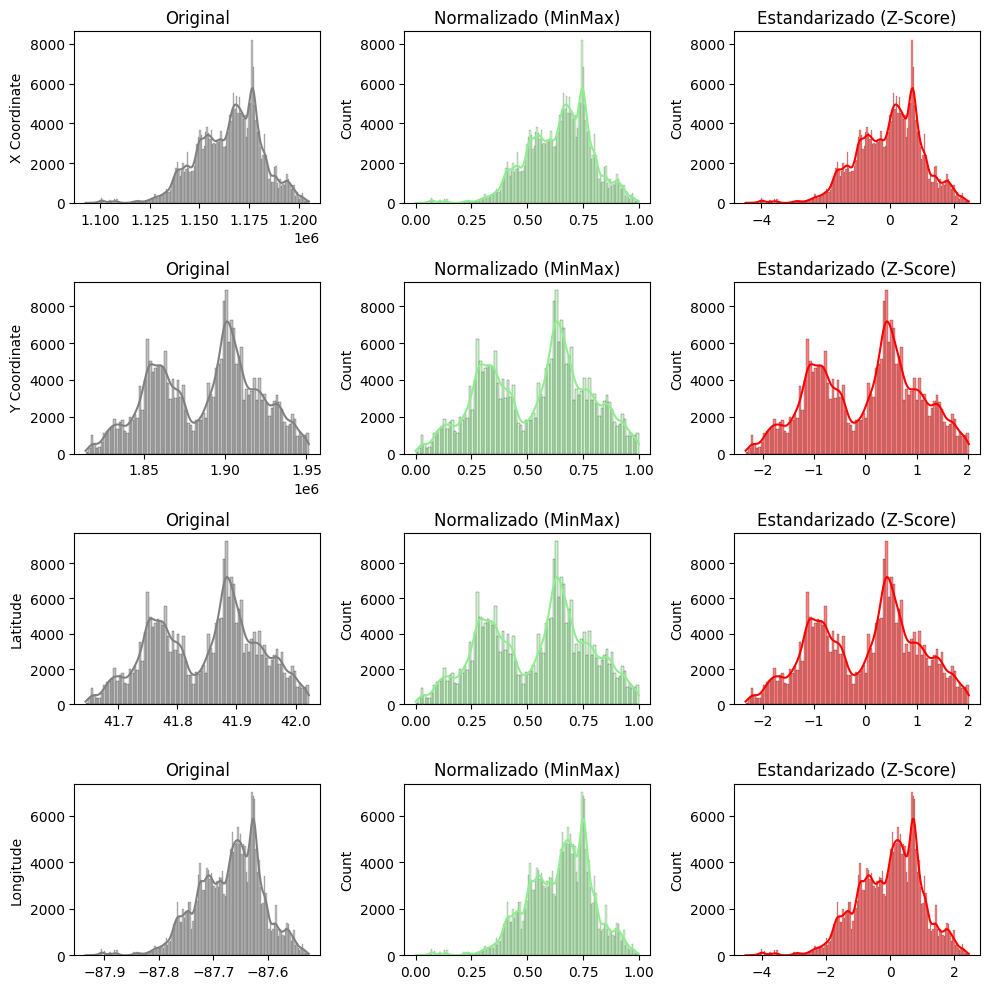

In [166]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10))
titles = ["Original", "Normalizado (MinMax)", "Estandarizado (Z-Score)"]
columns = ['X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude']
# Recorrer cada variable y graficarla en las tres columnas
for i, col in enumerate(columns):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="gray")
    sns.histplot(df_normalized[col], kde=True, ax=axes[i, 1], color="lightgreen")
    sns.histplot(df_standardized[col], kde=True, ax=axes[i, 2], color="red")

    # Etiquetas
    axes[i, 0].set_ylabel(col)
    for j in range(3):
        axes[i, j].set_xlabel("")
        axes[i, j].set_title(titles[j])

# Ajustar el layout
plt.tight_layout()
plt.show()

In [215]:
df["latitude_cat"] = pd.cut(df['latitude_scaled'], bins=3, labels=["south", "center", "north"])
df["longitude_cat"] = pd.cut(df['longitude_scaled'], bins=3, labels=["west", "center", "east"])
df["y_coordinate_cat"] = pd.cut(df['y_coordinate_scaled'], bins=3, labels=["south", "center", "north"])
df["x_coordinate_cat"] = pd.cut(df['x_coordinate_scaled'], bins=3, labels=["west", "center", "east"])

In [ ]:
kbin_kmeans = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
df["kbin_latitude"] = kbin_kmeans.fit_transform(df[['latitude_scaled']]).astype(int)
df["kbin_longitude"] = kbin_kmeans.fit_transform(df[['longitude_scaled']]).astype(int)
df["kbin_x_coordinate"] = kbin_kmeans.fit_transform(df[['x_coordinate_scaled']]).astype(int)
df["kbin_y_coordinate"] = kbin_kmeans.fit_transform(df[['y_coordinate_scaled']]).astype(int)
df.head(10)

,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,...,date_dt,part_of_day,month,day_week,Arrest_code,Domestic_code,kbin_latitude,kbin_longitude,kbin_x_coordinate,kbin_y_coordinate
0,12/31/2024 11:58:00 PM,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,332,3,...,2024-12-31 23:58:00,Night,12,Tuesday,0,0,0,2,2,0
1,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,223,2,...,2024-12-31 23:56:00,Night,12,Tuesday,1,1,0,2,2,0
2,12/31/2024 11:55:00 PM,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,834,8,...,2024-12-31 23:55:00,Night,12,Tuesday,0,1,0,0,0,0
3,12/31/2024 11:53:00 PM,066XX S GREENWOOD AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,321,3,...,2024-12-31 23:53:00,Night,12,Tuesday,0,0,0,2,2,0
4,12/31/2024 11:50:00 PM,012XX N MENARD AVE,0460,BATTERY,SIMPLE,SIDEWALK,False,False,2531,25,...,2024-12-31 23:50:00,Night,12,Tuesday,0,0,1,0,0,1
5,12/31/2024 11:46:00 PM,021XX W CULLERTON ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,1234,12,...,2024-12-31 23:46:00,Night,12,Tuesday,0,1,1,1,1,1
6,12/31/2024 11:45:00 PM,018XX W MAYPOLE AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,1223,12,...,2024-12-31 23:45:00,Night,12,Tuesday,0,0,1,1,1,1
7,12/31/2024 11:45:00 PM,117XX S STATE ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,532,5,...,2024-12-31 23:45:00,Night,12,Tuesday,0,1,0,2,2,0
8,12/31/2024 11:42:00 PM,029XX W CHICAGO AVE,1345,CRIMINAL DAMAGE,TO CITY OF CHICAGO PROPERTY,CTA BUS,False,False,1211,12,...,2024-12-31 23:42:00,Night,12,Tuesday,0,0,1,1,1,1
9,12/31/2024 11:40:00 PM,0000X S OAKLEY BLVD,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,1223,12,...,2024-12-31 23:40:00,Night,12,Tuesday,0,0,1,1,1,1


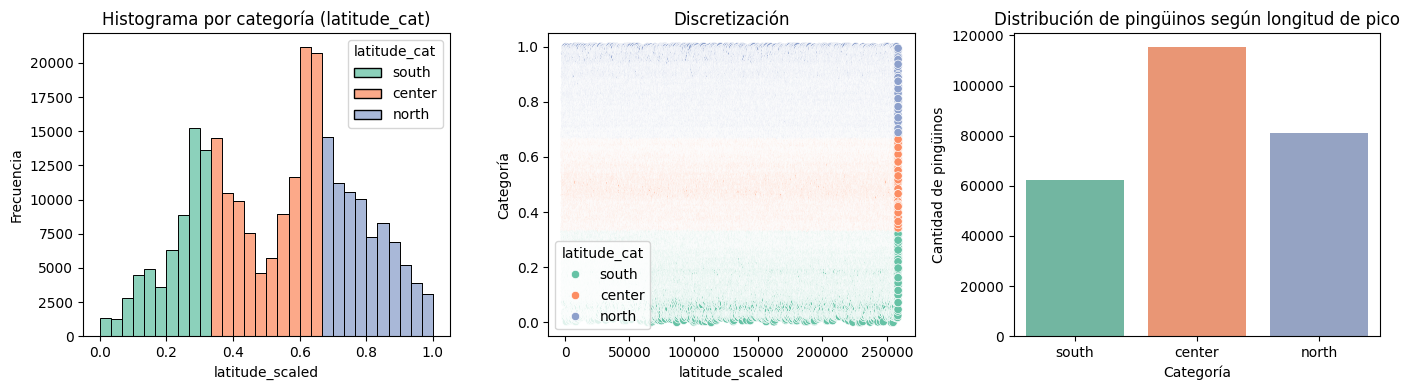

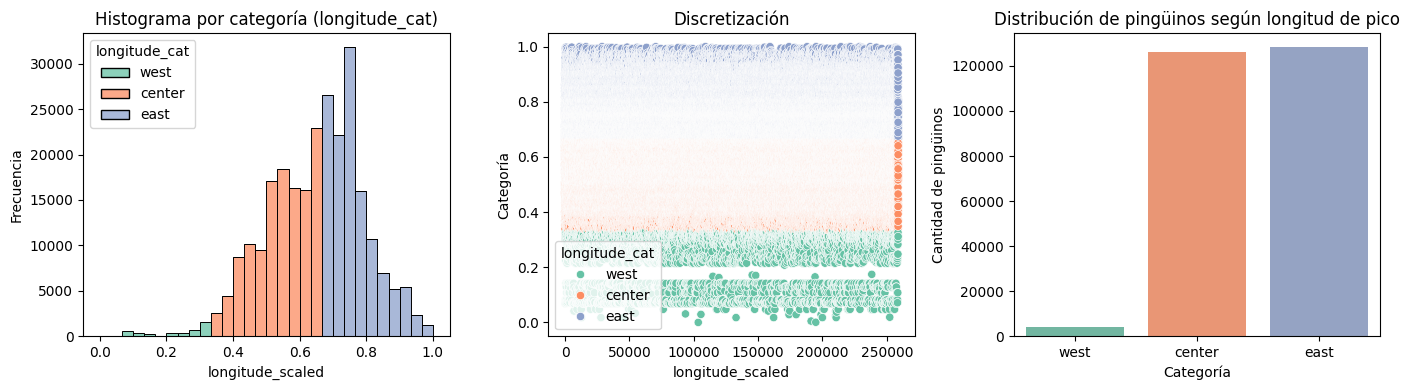

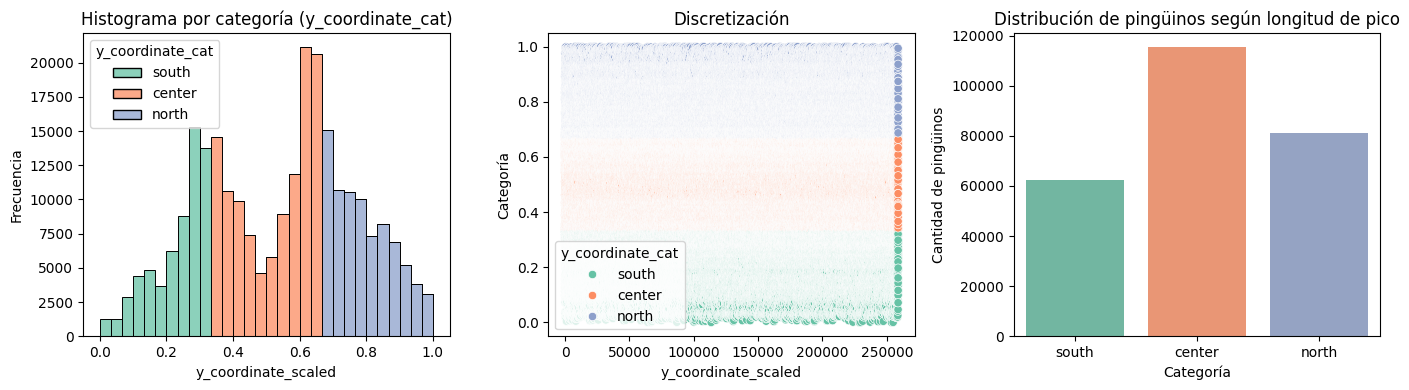

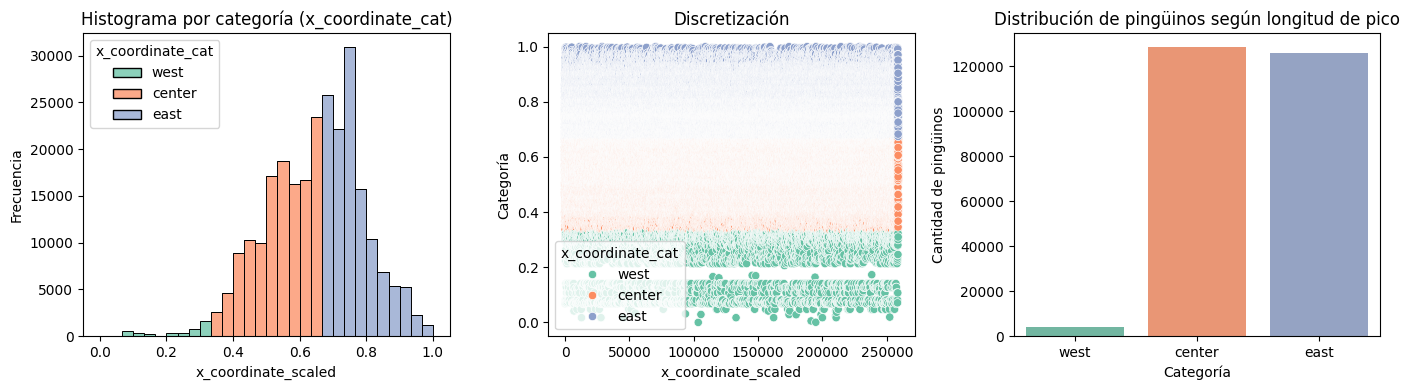

In [216]:
titles = ['latitude_scaled', 'longitude_scaled', 'y_coordinate_scaled', 'x_coordinate_scaled']
columns = ['latitude_cat', 'longitude_cat', 'y_coordinate_cat', 'x_coordinate_cat']
# Recorrer cada variable y graficarla en las tres columnas
for i, col in enumerate(columns):
    plot(columns[i], titles[i])


### Balancear

In [ ]:
df['Arrest'].value_counts()

Arrest
False    223065
True      35689
Name: count, dtype: int64

In [234]:
def shannon_entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

def plot(y):
    fig, axes = plt.subplots(figsize=(4, 4))
    sns.countplot(x=y, hue=y, palette="Set2", ax=axes)
    
    axes.set_xlabel("Arresto")
    axes.set_ylabel("Cantidad")
    axes.set_title(f"Distribución de la variable {target}")

    plt.tight_layout()
    plt.show()

def info(y):
    print("Proporción de clases:")
    print(y.value_counts(normalize=True))
    entropy = shannon_entropy(y)
    print("\nEntropía de Shannon:", entropy)
    plot(y)

Proporción de clases:
arrest_code
0    0.862074
1    0.137926
Name: proportion, dtype: float64

Entropía de Shannon: 0.578780090717355


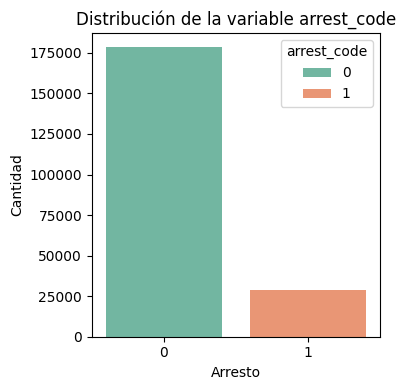

In [235]:
target = 'arrest_code'
X = df.drop(columns=[target])
y = df[target]

# Separa en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

info(y_train) # datos originales

Proporción de clases:
arrest_code
0    0.5
1    0.5
Name: proportion, dtype: float64

Entropía de Shannon: 1.0


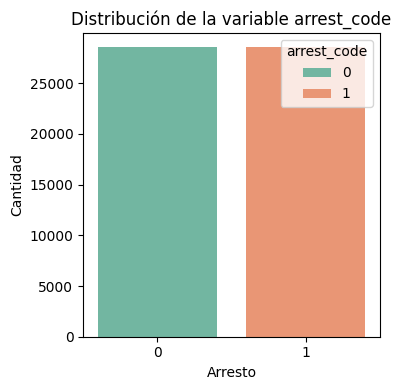

In [238]:
# Undersampling
undersample = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = undersample.fit_resample(X_train, y_train)
info(y_train_us)

## Eda Automatico

In [31]:
import pandas as pd
import seaborn as sns
from ydata_profiling import ProfileReport
import webbrowser
import os
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'ydata_profiling'

In [ ]:
df_2 = pd.read_csv('./dataset/Crimes_-_2024_20251103.csv', na_values='sin especificar', encoding='ISO-8859-1')